# 접근성 분석을 위한 네트워크 데이터 구축 
목적: 
- OSM 네트워크 데이터 수집 및 전처리
- 서울시 버스, 지하철 정류장 point 결합
- 문화누리카드 가맹점(공급)과 서울시 문화누리카드 추정 대상자 100m 래스터 데이터와 결합


In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pathlib
import numpy as np
import pathlib
from matplotlib.colors import LinearSegmentedColormap
import mapclassify as mc
import osmnx as ox
import networkx as nx
from collections import defaultdict

salmon_cmap = LinearSegmentedColormap.from_list(
    "salmon_cmap",
    ["#fff5f0", "#fddbc7", "#f4a582", "#ef8a62", "#d6604d", "#b2182b"]
)

plt.rcParams["font.family"] = "Noto Sans KR"

BASE_PATH = pathlib.Path().resolve()
if BASE_PATH.name == 'notebooks':
    BASE_PATH = BASE_PATH.parent.parent

if BASE_PATH.name == 'analysis_table':
    BASE_PATH == BASE_PATH.parent

ANALYSIS_PATH = BASE_PATH / "analysis_table"
ANALYSIS_PATH.mkdir(parents = True, exist_ok = True)

DATA_PATH = ANALYSIS_PATH / "data"
DATA_PATH.mkdir(parents = True, exist_ok = True)

INPUT_PATH = DATA_PATH / "input"
INPUT_PATH.mkdir(parents = True, exist_ok=True)

OUTPUT_PATH = DATA_PATH / "output"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

IMAGE_PATH = ANALYSIS_PATH / "image"
IMAGE_PATH.mkdir(parents=True, exist_ok=True)

RAW_PATH = BASE_PATH / "data" / "raw"

SPATIAL_PATH = RAW_PATH / "spatial"

NETWORK_PATH = INPUT_PATH / "network"
NETWORK_PATH.mkdir(parents=True, exist_ok=True)

WALK_PATH = NETWORK_PATH / 'walk'
WALK_PATH.mkdir(parents=True, exist_ok=True)

TRANSIT_PATH = NETWORK_PATH / "transit"
TRANSIT_PATH.mkdir(parents=True, exist_ok=True)



## 문화누리 100m 격자 대상자, 가맹점 데이터 불러오기

In [2]:
grid = gpd.read_file(OUTPUT_PATH / "서울시_100m_문화누리추정인구수.gpkg" )
store = gpd.read_file(OUTPUT_PATH / "서울시_문화누리카드_가맹점_2026.gpkg")

display(grid.head(10),
        store.head(10))

,GRID_CD,행정동코드,시군구,행정동,중심점_x,중심점_y,원본_인구수,주거면적,주택수,공시지가,추정_인구수,문화누리대상자_추정_인구수,GRID_CD_500,geometry
0,다사603367,11220670,서초구,양재2동,960350.0,1936750.0,0.0,0.0,0.0,21500.000000,0,0.0,다사60a36b,"POLYGON ((960300 1936700, 960300 1936800, 9604..."
1,다사604367,11220670,서초구,양재2동,960450.0,1936750.0,0.0,0.0,0.0,21949.995000,0,0.0,다사60a36b,"POLYGON ((960400 1936700, 960400 1936800, 9605..."
2,다사605367,11220670,서초구,양재2동,960550.0,1936750.0,0.0,0.0,0.0,30233.336667,0,0.0,다사60b36b,"POLYGON ((960500 1936700, 960500 1936800, 9606..."
3,다사615367,11220680,서초구,내곡동,961550.0,1936750.0,0.0,0.0,0.0,77118.103333,0,0.0,다사61b36b,"POLYGON ((961500 1936700, 961500 1936800, 9616..."
4,다사602368,11220670,서초구,양재2동,960250.0,1936850.0,0.0,0.0,0.0,21699.990000,0,0.0,다사60a36b,"POLYGON ((960200 1936800, 960200 1936900, 9603..."
5,다사603368,11220670,서초구,양재2동,960350.0,1936850.0,0.0,0.0,0.0,21949.995000,0,0.0,다사60a36b,"POLYGON ((960300 1936800, 960300 1936900, 9604..."
6,다사604368,11220670,서초구,양재2동,960450.0,1936850.0,0.0,0.0,0.0,22900.000000,0,0.0,다사60a36b,"POLYGON ((960400 1936800, 960400 1936900, 9605..."
7,다사605368,11220670,서초구,양재2동,960550.0,1936850.0,0.0,0.0,0.0,21700.000000,0,0.0,다사60b36b,"POLYGON ((960500 1936800, 960500 1936900, 9606..."
8,다사606368,11220670,서초구,양재2동,960650.0,1936850.0,0.0,0.0,0.0,21500.000000,0,0.0,다사60b36b,"POLYGON ((960600 1936800, 960600 1936900, 9607..."
9,다사607368,11220670,서초구,양재2동,960750.0,1936850.0,0.0,0.0,0.0,30233.336667,0,0.0,다사60b36b,"POLYGON ((960700 1936800, 960700 1936900, 9608..."


,가맹점_ID,가맹점명,시군구,주소,위도,경도,대분류,중분류,소분류,전화결제,장애인친화시설,찾아가는문화서비스,이용정보,연관검색어,이용분류_상세내용,URL,geometry
0,STORE_00001,(주) 드림네트웍스투어,강남구,서울 강남구 테헤란로 33길 18서울철강빌딩 5층 531호,37.502965,127.039322,관광,여행사,여행사,0,0,0,NaN,#관광#여행사#국내여행#국내여행사#(주) 드림네트웍스투어,NaN,NaN,POINT (959282.133 1944954.925)
1,STORE_00002,(주) 보배렌트카,강남구,서울 강남구 광평로10길 50 2층 42호 보배렌트카,37.481063,127.083253,관광,교통수단,렌터카,0,0,0,NaN,#관광#교통수단#렌터카#렌트#(주) 보배렌트카,NaN,NaN,POINT (963154.316 1942506.922)
2,STORE_00003,(주) 에이치렌터카,강남구,서울 강남구 학동로 342 7층 723호,37.516751,127.040857,관광,교통수단,렌터카,0,0,0,NaN,#관광#교통수단#렌터카#렌트#(주) 에이치렌터카,NaN,NaN,POINT (959425.27 1946483.677)
3,STORE_00004,(주)굿네이버트래블,강남구,서울특별시 강남구 테헤란로 406 샹제리제센터 A동 14080호,37.504388,127.049989,관광,여행사,여행사,0,0,0,저희 굿네이버트래블은 그동안의 축적된 여행업의 경험으로 지방 또는 여행을 자주 접하...,#관광#여행#나드리#축제#페스타#문화#공연#스포츠,NaN,NaN,POINT (960225.742 1945108.28)
4,STORE_00005,(주)대명네트웍스,강남구,서울 강남구 테헤란로 222,37.501623,127.040756,관광,여행사,여행사,0,0,0,NaN,#관광#여행사#국내여행#국내여행사#(주)대명네트웍스,NaN,NaN,POINT (959408.154 1944805.419)
5,STORE_00006,(주)롯데렌터카 논현점(롯데렌달(주)),강남구,서울특별시 강남구 학동로 216 성보빌딩 102호,37.514309,127.032795,관광,교통수단,렌터카,0,0,0,차량 렌탈,#관광#교통수단#렌트카#렌터카#롯데렌트카#롯데렌터카#차량대여#롯데렌터카 논현점#롯데...,NaN,NaN,POINT (958711.477 1946216.27)
6,STORE_00007,(주)민음북스,강남구,서울 강남구 신사동506번지 강남출판문화센터 5층,37.520742,127.019410,문화,도서,도서,0,0,0,NaN,#문화#도서#서점#서적#문고#책방#(주)민음북스,NaN,NaN,POINT (957532.238 1946935.976)
7,STORE_00008,(주)서울오션아쿠아리움 (코엑스아쿠아리움),강남구,서울특별시 강남구 영동대로 513 코엑스몰 B1,37.566826,126.978652,관광,관광지,테마파크,0,0,0,수족관 입장권,#문화#공연#체험#수족관#관광#관광지#테마파크#여행#아쿠아리움#(주)서울오션아쿠아리움,NaN,https://www.coexaqua.com,POINT (953958.972 1952067.929)
8,STORE_00009,(주)석세스파트너,강남구,서울 강남구 테헤란로 406에이-120 지하1층,37.504382,127.049965,문화,도서,도서,0,0,0,NaN,#문화#도서#서점#서적#문고#책방#(주)석세스파트너,NaN,NaN,POINT (960223.591 1945107.536)
9,STORE_00010,(주)술술,강남구,서울 강남구 도곡동 339-2 서울시여성창업플라자 203호,37.490716,127.054928,문화,문화체험,문화체험,1,0,0,"전통 매듭을 활용한 악세사리, 인테리어 소품 만들기를 통해 전통문화를 체험해볼 수 ...",#문화체험#전통매듭#공예#소품#만들기,-프로그램 명 : 술술과 함께 매듭이 술술 (전통매듭 체험)<br>\n-유형 : 문...,NaN,POINT (960655.097 1943589.329)


## OSM 세팅

In [3]:
ox.settings.use_cache = True
ox.settings.timeout = 300

place = "Seoul, south korea"

## 서울시 도보 그래프 다운로드

In [ ]:
# 서울 외곽 경계 데이터 불러오기

bound = gpd.read_file(SPATIAL_PATH / "boundary" / "BND_ADM_DONG_PG.shp")
bound.head()

seoul_idx = bound["ADM_CD"].astype(str).str.startswith('11').copy()

seoul_bound = bound[seoul_idx].dissolve()

seoul_bound = seoul_bound[["geometry"]].reset_index(drop=True)

# 외곽 경계 확장 (버퍼 1000)
seoul_bound_5179 = seoul_bound.to_crs("EPSG:5179")
seoul_buffer_5179 = seoul_bound_5179.buffer(1000)

seoul_buffer_4326 = (
    gpd.GeoSeries(seoul_buffer_5179, crs="EPSG:5179")
    .to_crs("EPSG:4326")
    .iloc[0]
)


# 버퍼 경계 기준 보행 네트워크 그래프 다운로드
walk = ox.graph_from_polygon(seoul_buffer_4326,
                             network_type = "walk",
                             simplify = True,
                             retain_all = False
                             )

walk = ox.project_graph(walk, 
                        to_crs = "EPSG:5179")


# 그래프 저장
ox.save_graphml(walk, 
                filepath = WALK_PATH / "osm_서울_도보_graph.graphml")

walk_nodes, walk_edges = ox.graph_to_gdfs(walk)

walk_nodes.to_file(WALK_PATH / "osm_서울_도보_nodes.gpkg", 
                   driver = "GPKG")

walk_edges.to_file(WALK_PATH / "osm_서울_도보_edges.gpkg",
                   driver = "GPKG")


# 저장 데이터 불러오기


In [5]:
walk_graph = ox.load_graphml(NETWORK_PATH / "walk" / "osm_서울_도보_graph.graphml")
print(type(walk_graph))
print(f'도보 그래프 crs" {walk_graph.graph["crs"]}')
print(f'도보 그래프 노드 개수" {len(walk_graph.nodes)}')
print(f'도보 그래프 엣지 개수" {len(walk_graph.edges)}')

# 그래프 crs 변경
walk_graph = ox.project_graph(walk_graph, to_crs = "EPSG:5179")
print(f'변경된 walk graph crs:{walk_graph.graph["crs"]}')

<class 'networkx.classes.multidigraph.MultiDiGraph'>
도보 그래프 crs" EPSG:5179
도보 그래프 노드 개수" 180285
도보 그래프 엣지 개수" 515136
변경된 walk graph crs:EPSG:5179


## 도보 그래프 데이터 EDA



walk node shape: (180285, 8)

walk node columns: Index(['y', 'x', 'street_count', 'highway', 'junction', 'ref', 'railway',
       'geometry'],
      dtype='str')

walk node crs: EPSG:5179

walk node geotype: <StringArray>
['Point']
Length: 1, dtype: str

walk node 결측치: 
y                    0
x                    0
street_count         0
highway         169207
junction        179571
ref             180090
railway         180207
geometry             0
dtype: int64
----------------------------------------------------------------------------------------------------

walk edge shape: (515136, 17)

walk edge columns: Index(['osmid', 'highway', 'name', 'oneway', 'reversed', 'length', 'geometry',
       'lanes', 'maxspeed', 'service', 'width', 'bridge', 'ref', 'tunnel',
       'junction', 'access', 'area'],
      dtype='str')

walk edge crs: EPSG:5179

walk edge geotype: <StringArray>
['LineString']
Length: 1, dtype: str

walk edge 결측치: 
osmid            0
highway          0
name        2343

,y,x,street_count,highway,junction,ref,railway,geometry
osmid,,,,,,,,
278159482,1.947525e+06,955592.375177,3,NaN,NaN,NaN,NaN,POINT (955592.375 1947525.468)
1378780898,1.947501e+06,955654.806498,3,NaN,NaN,NaN,NaN,POINT (955654.806 1947501.181)
1378780857,1.947526e+06,955569.650260,4,NaN,NaN,NaN,NaN,POINT (955569.65 1947525.845)
1378780918,1.947527e+06,955601.160027,3,NaN,NaN,NaN,NaN,POINT (955601.16 1947527.418)
1378780871,1.947419e+06,955629.289992,3,NaN,NaN,NaN,NaN,POINT (955629.29 1947418.939)
4203603349,1.947491e+06,955690.733760,3,NaN,NaN,NaN,NaN,POINT (955690.734 1947491.016)
1378780958,1.947513e+06,955489.876147,3,NaN,NaN,NaN,NaN,POINT (955489.876 1947512.625)
1378780897,1.947565e+06,955603.170900,3,NaN,NaN,NaN,NaN,POINT (955603.171 1947564.752)
436843916,1.947562e+06,955526.961214,4,NaN,NaN,NaN,NaN,POINT (955526.961 1947561.998)


osmid      highway    name  oneway reversed  \
u          v          key                                                    
278159482  1378780898 0     25524218  residential   보광로7길   False    False   
           1378780857 0     97836950     tertiary     장문로   False    False   
           1378780918 0     97836950     tertiary     장문로   False     True   
1378780898 278159482  0     25524218  residential   보광로7길   False     True   
           1378780871 0    123724539  residential   보광로7길   False    False   
           4203603349 0     25524218  residential   보광로7길   False    False   
1378780857 278159482  0     97836950     tertiary     장문로   False     True   
           1378780958 0    123724524  residential   장문로6길   False     True   
           1378780897 0    123724532  residential  장문로17길   False    False   
           436843916  0    305827269     tertiary     장문로   False    False   

                              length  \
u          v          key              
278159482  1378780898 0    66.892380   
           1378780857 0    22.682960   
           1378780918 0     8.982724   
1378780898 278159482  0    66.892380   
           1378780871 0    86.272336   
           4203603349 0    37.512384   
1378780857 278159482  0    22.682960   
           1378780958 0    82.277159   
           1378780897 0    51.747416   
           436843916  0    56.186276   

                                                                    geometry  \
u          v          key                                                      
278159482  1378780898 0    LINESTRING (955592.375 1947525.468, 955654.806...   
           1378780857 0    LINESTRING (955592.375 1947525.468, 955569.65 ...   
           1378780918 0    LINESTRING (955592.375 1947525.468, 955601.16 ...   
1378780898 278159482  0    LINESTRING (955654.806 1947501.181, 955592.375...   
           1378780871 0    LINESTRING (955654.806 1947501.181, 955629.29 ...   
           4203603349 0    LINESTRING (955654.806 1947501.181, 955676.226...   
1378780857 278159482  0    LINESTRING (955569.65 1947525.845, 955592.375 ...   
           1378780958 0    LINESTRING (955569.65 1947525.845, 955554.371 ...   
           1378780897 0    LINESTRING (955569.65 1947525.845, 955596.097 ...   
           436843916  0    LINESTRING (955569.65 1947525.845, 955543.937 ...   

                          lanes maxspeed service width bridge  ref tunnel  \
u          v          key                                                   
278159482  1378780898 0     NaN      NaN     NaN   NaN    NaN  NaN    NaN   
           1378780857 0     NaN      NaN     NaN   NaN    NaN  NaN    NaN   
           1378780918 0     NaN      NaN     NaN   NaN    NaN  NaN    NaN   
1378780898 278159482  0     NaN      NaN     NaN   NaN    NaN  NaN    NaN   
           1378780871 0     NaN      NaN     NaN   NaN    NaN  NaN    NaN   
           4203603349 0     NaN      NaN     NaN   NaN    NaN  NaN    NaN   
1378780857 278159482  0     NaN      NaN     NaN   NaN    NaN  NaN    NaN   
           1378780958 0     NaN      NaN     NaN   NaN    NaN  NaN    NaN   
           1378780897 0     NaN      NaN     NaN   NaN    NaN  NaN    NaN   
           436843916  0     NaN      NaN     NaN   NaN    NaN  NaN    NaN   

                          junction access area  
u          v          key                       
278159482  1378780898 0        NaN    NaN  NaN  
           1378780857 0        NaN    NaN  NaN  
           1378780918 0        NaN    NaN  NaN  
1378780898 278159482  0        NaN    NaN  NaN  
           1378780871 0        NaN    NaN  NaN  
           4203603349 0        NaN    NaN  NaN  
1378780857 278159482  0        NaN    NaN  NaN  
           1378780958 0        NaN    NaN  NaN  
           1378780897 0        NaN    NaN  NaN  
           436843916  0        NaN    NaN  NaN

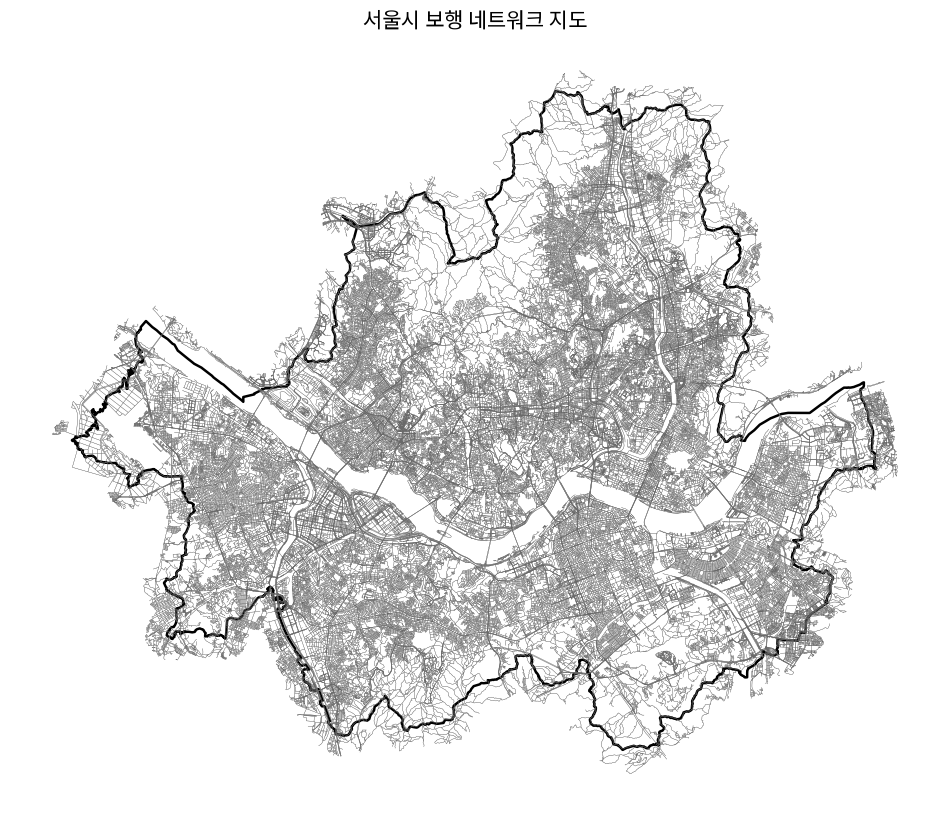

In [6]:
# walk graph nodes, edges 테이블 만들기
walk_node, walk_edge = ox.graph_to_gdfs(walk_graph)

# node 점검
print(f'\nwalk node shape: {walk_node.shape}')
print(f'\nwalk node columns: {walk_node.columns}')
print(f'\nwalk node crs: {walk_node.crs}')
print(f'\nwalk node geotype: {walk_node.geometry.geom_type.unique()}')
print(f'\nwalk node 결측치: \n{walk_node.isna().sum()}')

# edge 점검
print('-'*100)
print(f'\nwalk edge shape: {walk_edge.shape}')
print(f'\nwalk edge columns: {walk_edge.columns}')
print(f'\nwalk edge crs: {walk_edge.crs}')
print(f'\nwalk edge geotype: {walk_edge.geometry.geom_type.unique()}')
print(f'\nwalk edge 결측치: \n{walk_edge.isna().sum()}')

display(walk_node.head(10), walk_edge.head(10))

# 시각 그래프로 데이터 분포 확인
fig, ax = plt.subplots(figsize=(12, 12))
seoul_bound.to_crs("EPSG:5179").plot(ax=ax,
                                     facecolor='None',
                                     edgecolor='black',
                                     linewidth=1.8)
walk_edge.plot(ax=ax,
                linewidth=0.2,
                edgecolor='dimgray')

ax.set_title("서울시 보행 네트워크 지도", fontsize=15)
plt.savefig(IMAGE_PATH / "서울시_보행_네트워크.png",
            pad_inches = 0.1,
            bbox_inches = 'tight',
            dpi = 240)
ax.set_axis_off()

    # walk node shape: (180285, 8)

    # walk node columns: Index(['y', 'x', 'street_count', 'highway', 'junction', 'ref', 'railway',
    #        'geometry'],
    #       dtype='str')

    # walk node crs: EPSG:5179

    # walk node geotype: <StringArray>
    # ['Point']
    # Length: 1, dtype: str

    # walk node 결측치: 
    # y                    0
    # x                    0
    # street_count         0
    # highway         169207
    # junction        179571
    # ref             180090
    # railway         180207
    # geometry             0
    # dtype: int64
    # ----------------------------------------------------------------------------------------------------

    # walk edge shape: (515136, 17)

    # walk edge columns: Index(['osmid', 'highway', 'name', 'oneway', 'reversed', 'length', 'geometry',
    #        'lanes', 'maxspeed', 'service', 'width', 'bridge', 'ref', 'tunnel',
    #        'junction', 'access', 'area'],
    #       dtype='str')

    # walk edge crs: EPSG:5179

    # walk edge geotype: <StringArray>
    # ['LineString']
    # Length: 1, dtype: str

    # walk edge 결측치: 
    # osmid            0
    # highway          0
    # name        234310
    # oneway           0
    # reversed         0
    # length           0
    # geometry         0
    # lanes       483360
    # maxspeed    499876
    # service     483738
    # width       511080
    # bridge      508964
    # ref         499380
    # tunnel      511064
    # junction    514528
    # access      510462
    # area        515128
    # dtype: int64

In [7]:
# 길이 확인
print(f'\nlength 결측:', walk_edge["length"].isna().sum())
display(walk_edge["length"].describe())

print(f'\n 노드 인덱스 중복', walk_node.index.duplicated().sum())
print(f'\n 엣지 인덱스 중복', walk_edge.index.duplicated().sum())


    # length 결측: 0
    # count    515136.000000
    # mean         59.641964
    # std          86.751897
    # min           0.155977
    # 25%          18.816888
    # 50%          38.584113
    # 75%          70.702963
    # max        5088.778661
    # Name: length, dtype: float64
        
    #  노드 인덱스 중복 0

    #  엣지 인덱스 중복 0
    
    # length 값 결측치 및 이상치 없음
    # 노드·엣지 인덱스 중복 없음 
    # 성공!


length 결측: 0


count    515136.000000
mean         59.641964
std          86.751897
min           0.155977
25%          18.816888
50%          38.584113
75%          70.702963
max        5088.778661
Name: length, dtype: float64


 노드 인덱스 중복 0

 엣지 인덱스 중복 0


## 격자 중심점, 가맹점 POI와 도보 노드 연결 (node snapping)

- 출발점(격자), 도착지(가맹점)의 노드를 최근접 알고리즘으로 연결

In [8]:
# 노드 스냅
walk_grid =grid.copy()
walk_grid = walk_grid.to_crs("EPSG:5179")

walk_store = store.copy()
walk_store = walk_store.to_crs("EPSG:5179")

walk_grid["도보_노드ID"] = ox.distance.nearest_nodes(walk_graph,
                                                 walk_grid["중심점_x"],
                                                 walk_grid["중심점_y"])

walk_store["도보_노드ID"] = ox.distance.nearest_nodes(walk_graph,
                                                  walk_store["geometry"].x,
                                                  walk_store["geometry"].y)

print('\n 격자 노드 결측값', walk_grid["도보_노드ID"].isna().sum())
print('\n 가맹점 노드 결측값', walk_store["도보_노드ID"].isna().sum())


 격자 노드 결측값 0

 가맹점 노드 결측값 0


## POI - 노드 스냅 거리 EDA
### 격자 중심점
    # 이상치 후보 점검
        # 격자 중심점과 최근접 도보 노드 간 스냅거리가 150m를 초과하는 격자를 이상치 후보로 정의하고 점검함(중심점 - 격자 외곽 최대 거리 약 50m).
        # 총 7,769개 격자가 이상치 후보로 확인됨.
        # 해당 격자의 문화누리대상자 추정 인구수가 대부분 0, 인구수 총합은 약 2356명으로, 주로 한강 주변, 산지, 서울시 외곽 경계부에 분포함.
        # 따라서 도보 네트워크 스냅거리 이상치가 최종 문화누리 수요 기반 접근성 분석에 미치는 영향은 제한적이라고 판단함.


### 가맹점 POI
    # 이상치 후보 점검
        # 가맹점 point와 최근접 노드 간 스냅거리 100m 초과를 이상치 후보로 정의하고 점검
        # 52개의 가맹점이 이상치 후보로 확인됨.
        # 이상치 후보는 주로 대형 스포츠 시설과 놀이공원이었으며 일부 서울 외곽의 도서 및 스포츠 시설임로 구성됨을 확인

격자 스냅거리 이상치 후보 개수: 7769
count    7769.000000
mean      266.336481
std       100.634559
min       150.039700
25%       185.179168
50%       237.901323
75%       324.128182
max       716.034855
Name: 도보_스냅거리, dtype: float64


,GRID_CD,시군구,행정동,중심점,문화누리대상자_추정_인구수,도보_노드ID,노드_geometry,도보_스냅거리
32981,다사378508,강서구,공항동,POINT (937850 1950850),0.0,2697134602,POINT (937872.552 1951565.68),716.034855
53330,다사517594,은평구,진관동,POINT (951750 1959450),0.0,3781355852,POINT (951563.35 1960137.811),712.686521
53331,다사518594,은평구,진관동,POINT (951850 1959450),0.0,3781355302,POINT (952509.286 1959658.284),691.404311
53329,다사516594,은평구,진관동,POINT (951650 1959450),0.0,3781353770,POINT (951398.241 1958817.316),680.933908
32615,다사379507,강서구,공항동,POINT (937950 1950750),0.0,8601203351,POINT (937786.196 1950097.842),672.414635
32982,다사379508,강서구,공항동,POINT (937950 1950850),0.0,7983746315,POINT (938503.072 1951224.622),668.004945
32616,다사380507,강서구,공항동,POINT (938050 1950750),0.0,7983746315,POINT (938503.072 1951224.622),656.155929
32614,다사378507,강서구,공항동,POINT (937850 1950750),0.0,8601203351,POINT (937786.196 1950097.842),655.271365
53161,다사518593,은평구,진관동,POINT (951850 1959350),0.0,10956655000,POINT (952249.586 1958844.506),644.355395
53160,다사517593,은평구,진관동,POINT (951750 1959350),0.0,3781353770,POINT (951398.241 1958817.316),638.346283



가맹점 스냅거리 이상치 후보 개수: 52
count     52.000000
mean     131.729515
std       32.088062
min      100.438699
25%      107.511198
50%      123.856640
75%      146.457310
max      243.074517
Name: 도보_스냅거리, dtype: float64


,가맹점_ID,가맹점명,중분류,소분류,시군구,geometry,도보_노드ID,노드_geometry,도보_스냅거리
1171,STORE_01172,서울어린이대공원 놀이동산,관광지,테마파크,광진구,POINT (962982.172 1950144.747),5938706626,POINT (962832.712 1950336.443),243.074517
3613,STORE_03614,KTX(용산역),교통수단,철도,용산구,POINT (952038.481 1947944.42),13781369086,POINT (951804.773 1947946.271),233.715564
1849,STORE_01850,우리아이유아동서점,도서,도서,도봉구,POINT (960428.684 1961294.009),7558527345,POINT (960411.305 1961496.574),203.309078
680,STORE_00681,대한항공 (발권-오프라인),교통수단,국내항공,강서구,POINT (939244.94 1950051.748),4656638624,POINT (939397.001 1949973.215),171.143046
1660,STORE_01661,시립노원청소년센터,체육시설,체육시설,노원구,POINT (961024.481 1960314.233),4682732864,POINT (961172.581 1960232.5),169.156696
1597,STORE_01598,마린스포츠센터,체육시설,체육시설,노원구,POINT (962590.215 1960207.942),6266023599,POINT (962564.589 1960040.981),168.916400
3148,STORE_03149,에듀갤러리(키즈스콜레강남송파),도서,도서,송파구,POINT (966845.238 1942087.211),12149794128,POINT (966719.172 1942187.164),160.882794
696,STORE_00697,라켓매니아,체육용품,체육용품,강서구,POINT (939865.629 1953028.169),3280286032,POINT (939906.376 1952878.332),155.277643
2373,STORE_02374,풋볼팬타지움㈜올리브크리에이티브,관광지,관광명소,마포구,POINT (946773.219 1952269.487),3052482047,POINT (946629.131 1952214.116),154.360729
2183,STORE_02184,FC서울 (서울월드컵경기장),스포츠관람,스포츠관람,마포구,POINT (946773.219 1952269.487),3052482047,POINT (946629.131 1952214.116),154.360729


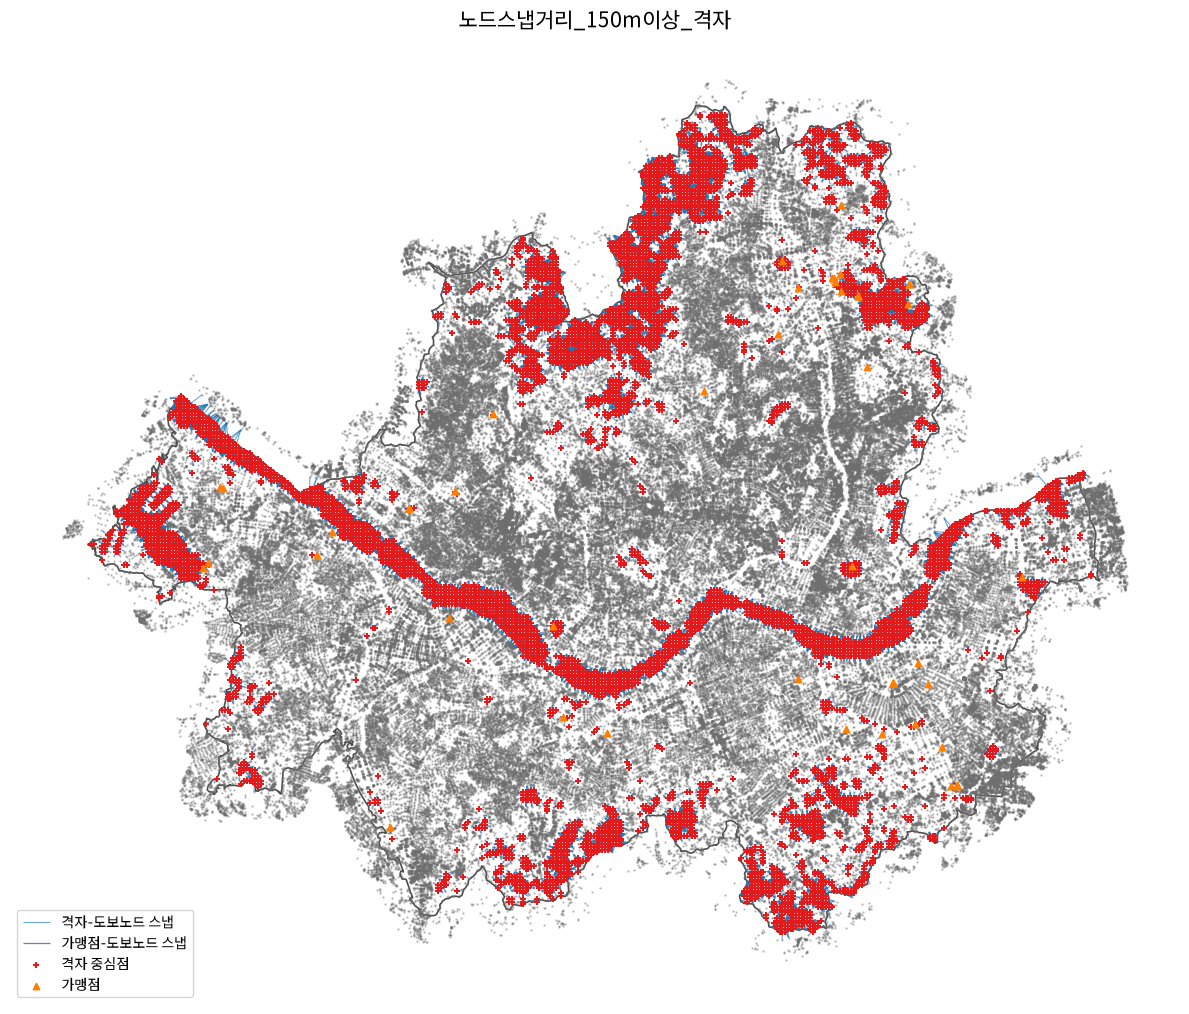

In [9]:
from shapely.geometry import LineString


# 스냅거리 계산
snap_node = walk_node[["geometry"]].copy()
snap_node = snap_node.rename(columns = {"geometry": "노드_geometry"})

walk_grid["중심점"] = gpd.points_from_xy(walk_grid["중심점_x"],
                                            walk_grid["중심점_y"],
                                            crs = "EPSG:5179")


walk_grid_snap = walk_grid[["GRID_CD", "시군구", "행정동", "중심점", "문화누리대상자_추정_인구수", "도보_노드ID"]].merge(snap_node,
                                 left_on = "도보_노드ID",
                                 right_index = True,
                                 how = 'left')

walk_grid_snap["도보_스냅거리"] = walk_grid_snap["중심점"].geometry.distance(walk_grid_snap["노드_geometry"])


walk_store_snap = walk_store[["가맹점_ID", "가맹점명", "중분류", "소분류", "시군구", "geometry","도보_노드ID"]].merge(snap_node,
                                   left_on = "도보_노드ID",
                                   right_index = True,
                                   how = 'left')

walk_store_snap["도보_스냅거리"] = walk_store_snap["geometry"].geometry.distance(walk_store_snap["노드_geometry"])




# 스냅거리 이상치 후보점검
# 격자: 150, 가맹점: 100m
# 격자
snap_out_grid_idx = walk_grid_snap["도보_스냅거리"] > 150
snap_out_grid = walk_grid_snap[snap_out_grid_idx]

print('격자 스냅거리 이상치 후보 개수:', snap_out_grid_idx.sum())
print(snap_out_grid["도보_스냅거리"].describe())
display(snap_out_grid.sort_values("도보_스냅거리", ascending=False).head(20))


# 가맹점
snap_out_store_idx = walk_store_snap["도보_스냅거리"] > 100
snap_out_store = walk_store_snap[snap_out_store_idx]

print("\n가맹점 스냅거리 이상치 후보 개수:", snap_out_store_idx.sum())
print(snap_out_store["도보_스냅거리"].describe())
display(snap_out_store.sort_values("도보_스냅거리", ascending=False).head(20))



# 시각화
# 격자 스냅 연결선
snap_out_grid_line = snap_out_grid.copy()
snap_out_grid_line["line"] = snap_out_grid_line.apply(
    lambda row: LineString([row["중심점"], row["노드_geometry"]]),
    axis=1
)
snap_out_grid_line = snap_out_grid_line.set_geometry("line")

# 가맹점 스냅 연결선
snap_out_store_line = snap_out_store.copy()
snap_out_store_line["line"] = snap_out_store_line.apply(
    lambda row: LineString([row["geometry"], row["노드_geometry"]]),
    axis=1
)
snap_out_store_line = snap_out_store_line.set_geometry("line")


fig, ax = plt.subplots(figsize=(12, 12))

# 서울 경계
seoul_bound_5179.plot(
    ax=ax,
    facecolor="none",
    edgecolor="#222222",
    linewidth=1.2,
    alpha=0.8,
    zorder=1
)


# 도보 네트워크 노드
walk_node.plot(
    ax=ax,
    color="#6e6e6e",
    markersize=0.6,
    alpha=0.35,
    zorder=3
)

# 격자 스냅 연결선
snap_out_grid_line.set_geometry("line").plot(
    ax=ax,
    color="#1f78b4",
    linewidth=0.8,
    alpha=0.65,
    zorder=4,
    label="격자-도보노드 스냅"
)

# 가맹점 스냅 연결선
snap_out_store_line.set_geometry("line").plot(
    ax=ax,
    color="#6a3d9a",
    linewidth=0.9,
    alpha=0.75,
    zorder=5,
    label="가맹점-도보노드 스냅"
)

# 격자 중심점
snap_out_grid_line.set_geometry("중심점").plot(
    ax=ax,
    markersize=18,
    color="#e31a1c",
    marker="+",
    zorder=6,
    label="격자 중심점"
)

# 가맹점
snap_out_store_line.set_geometry("geometry").plot(
    ax=ax,
    markersize=22,
    color="#ff7f00",
    marker="^",
    zorder=7,
    label="가맹점"
)

ax.legend(loc="lower left", frameon=True)
ax.set_axis_off()
plt.tight_layout()
plt.title("노드스냅거리_150m이상_격자", fontsize=15)
plt.savefig(IMAGE_PATH / "노드스냅거리_150m이상_격자.png",
            pad_inches = 0.1, 
            bbox_inches = 'tight',
            dpi = 240)

plt.show()

## 도보 기준 접근성 허용 거리 metric 결정

- 수식:

  `도보_최종거리 = 격자_스냅거리_보정 + 도보_네트워크거리 + 가맹점_스냅거리`

  `격자_스냅거리_보정 = max(격자_스냅거리 - 35.35m, 0)`

- 설계:

  도보 접근성 기준은 마을단위시설 접근 기준인 도보 약 10분·750m를 적용함. 
  
  100m 격자의 실제 출발 위치가 중심점과 다를 수 있으므로, 격자 내부 위치 불확실성을 고려해 중심점-격자 내부 거리 범위 0~70.7m의 평균값인 35.35m를 격자 스냅거리에서 차감함. 
  
  가맹점은 위치가 point로 특정되어 있어 스냅거리를 그대로 반영함.


In [10]:
# 도보 접근성 거리 범위
walk_limit = 750

# 격자 - 노드 스냅거리 보정 (격자 내 최대 거리 + 최소 거리) / 2
grid_snap_offset = (70.7 + 0) / 2

## Dijkstra 알고리즘 기반 도보 네트워크 분석 수행

- 도보
    - 중분류 필터: 도서, 문화체험, 음악, 영상, 체육시설, 체육용품 등 생활 시설 중심으로 분류
    - 접근성 허용 거리: 도보 15분 (750m)


- 대중교통(버스, 지하철) 
    - 중분류 필터: 미술, 공연, 스포츠관람, 관광지 등 대형 시설 중심으로 분류
    - 접근성 허용 거리: 대중교통 15분 (10km)

* 미포함 중분류: 여행사, 교통수단, 숙박

In [ ]:
# 출발점 격자 하나에 대해 테스트
from collections import defaultdict # 딕셔너리 생성시 오류 방지

# 가맹점 노드별로 묶기
    # 가맹점과 매칭된 도착 노드 수:4041
node_store_dict = defaultdict(list)

for idx, row in walk_store_snap.iterrows():
    node_store_dict[row["도보_노드ID"]].append(idx) # 딕셔너리에 key와 value를 지정해서 넣는 함수

print(f'가맹점과 매칭된 도착 노드 수:{len(node_store_dict)}')

# 격자 하나 테스트
# 실험격자
test_grid = walk_grid_snap.iloc[1006]

# 실험 격자 노드 ID
test_grid_node = test_grid["도보_노드ID"]

# 스냅거리 보정(스냅거리 - 격자 보정 거리)
grid_snap_corrected = max(
    test_grid["도보_스냅거리"] - grid_snap_offset, 
    0)

network_cutoff = walk_limit - grid_snap_corrected

length_test = nx.single_source_dijkstra_path_length(walk_graph,
                                                    test_grid_node,
                                                    cutoff = network_cutoff,
                                                    weight = 'length')


print(f"테스트 그리드의 도달 가능한 노드 수: {len(length_test)}")
length_test

In [ ]:
test_rows = []

for reached_node, reached_length in length_test.items(): #key와 value를 이터러블한 튜플로 묶음
    store_idx_list = node_store_dict.get(reached_node, []) # 도달 노드가 노드-가맹점 딕셔너리에 있는지 확인
    # get 함수?
    for store_idx in store_idx_list:
        store_row = walk_store_snap.loc[store_idx] # idx리스트에서 매칭된 가맹점 idx 가져와서 row로저장
        
        final_dist = (grid_snap_corrected
                      + reached_length
                      + store_row["도보_스냅거리"])
        
        if final_dist <= walk_limit:
            test_rows.append({
                "GRID_CD": test_grid["GRID_CD"],
                "가맹점_ID": store_row["가맹점_ID"],
                "가맹점명": store_row["가맹점명"],
                "중분류": store_row["중분류"],
                "소분류": store_row["소분류"],
                "도보_네트워크거리": reached_length,
                "격자_스냅거리": test_grid["도보_스냅거리"],
                "격자_스냅거리_보정": grid_snap_corrected,
                "가맹점_스냅거리": store_row["도보_스냅거리"],
                "도보_최종거리": final_dist,
            })

walk_network_df_test = pd.DataFrame(test_rows)
walk_network_df_test.head()

reachable_nodes = set(length_test.keys())
store_nodes = set(node_store_dict.keys())

reachable_store_nodes = reachable_nodes & store_nodes

print(f"도달 가능한 전체 노드 수: {len(reachable_nodes)}")
print(f"가맹점이 붙은 전체 노드 수: {len(store_nodes)}")
print(f"도달 가능한 가맹점 노드 수: {len(reachable_store_nodes)}")
for node in reachable_store_nodes:
    print("도달 가맹점 노드:", node)
    print("노드까지 네트워크거리:", length_test[node])
    print("해당 노드에 붙은 가맹점 index:", node_store_dict[node])
    

display(walk_network_df_test)

store_idx = 1428
store_row = walk_store_snap.loc[store_idx]

network_dist = length_test[13072586897]

final_dist = (
    grid_snap_corrected
    + network_dist
    + store_row["도보_스냅거리"]
)

print("격자 스냅거리 보정:", grid_snap_corrected)
print("네트워크 거리:", network_dist)
print("가맹점 스냅거리:", store_row["도보_스냅거리"])
print("최종 도보거리:", final_dist)
print("접근 가능 여부:", final_dist <= walk_limit)

display(store_row[["가맹점_ID", "가맹점명", "중분류", "소분류", "도보_스냅거리"]])

In [ ]:
walk_grid_snap["격자_스냅거리_보정"] = (
    walk_grid_snap["도보_스냅거리"] - grid_snap_offset
).clip(lower=0)


# 1. 가맹점을 도보 노드별로 묶기
node_store_dict = defaultdict(list)

for idx, row in walk_store_snap.iterrows():
    node_store_dict[row["도보_노드ID"]].append(idx)

# 가맹점 행 조회용
store_info = walk_store_snap.to_dict("index")

print(f"가맹점이 붙은 도보 노드 수: {len(node_store_dict)}")


# 2. 전체 격자에 대해 접근 가능한 가맹점 pair 생성
walk_reach_rows = []

grid_node_group = walk_grid_snap.groupby("도보_노드ID")
total_node_count = walk_grid_snap["도보_노드ID"].nunique()

for n, (grid_node, grid_group) in enumerate(grid_node_group, start=1):
    
    if grid_node not in walk_graph:
        continue
    
    # 같은 도보 노드에 붙은 격자들은 네트워크 도달 노드가 같음
    # 다만 격자별 스냅거리 보정값은 다르므로 최종 판정은 격자별로 함
    min_grid_snap = grid_group["격자_스냅거리_보정"].min()
    network_cutoff = walk_limit - min_grid_snap
    
    if network_cutoff <= 0:
        continue
    
    # 출발 노드에서 network_cutoff 이내 도달 가능한 노드와 거리 계산
    lengths = nx.single_source_dijkstra_path_length(
        walk_graph,
        grid_node,
        cutoff=network_cutoff,
        weight="length"
    )
    
    # 도달 가능한 노드 중 가맹점이 붙은 노드만 후보로 추림
    candidate_list = []
    
    for reached_node, network_dist in lengths.items():
        store_idx_list = node_store_dict.get(reached_node, [])
        
        for store_idx in store_idx_list:
            candidate_list.append((store_idx, network_dist))
    
    if len(candidate_list) == 0:
        continue
    
    # 같은 출발 노드에 붙은 각 격자별로 최종거리 판정
    for grid_idx, grid_row in grid_group.iterrows():
        grid_snap_corrected = grid_row["격자_스냅거리_보정"]
        
        for store_idx, network_dist in candidate_list:
            store_row = store_info[store_idx]
            
            final_dist = (
                grid_snap_corrected
                + network_dist
                + store_row["도보_스냅거리"]
            )
            
            if final_dist <= walk_limit:
                 walk_reach_rows.append({
                    "GRID_CD": grid_row["GRID_CD"],
                    "도보_네트워크거리": network_dist,
                    "격자_스냅거리": grid_row["도보_스냅거리"],
                    "격자_스냅거리_보정": grid_snap_corrected,
                    "가맹점_스냅거리": store_row["도보_스냅거리"],
                    "도보_최종거리": final_dist,
                    "가맹점_ID": store_row["가맹점_ID"],
                })
    
    if n % 1000 == 0:
        print(f"{n:,} / {total_node_count:,}개 출발 노드 처리 완료")


grid_store_walk_reach = pd.DataFrame(walk_reach_rows)

print(f"도보 접근 가능 pair 수: {len(grid_store_walk_reach)}")
display(grid_store_walk_reach.head())

## 도보 네트워크 분석 결과 검토

    # 격자코드 - 가맹점 ID 중복 확인: 0
    # 기준 거리 초과 레코드 확인: 0
    # 연결된 격자 개수: 41234
    # 연결된 가맹점 개수: 4701
    
    # 격자별 접근가능한 가맹점 통계량 확인
    #          가맹점_개수
    # count  41234.000000
    # mean       9.685721
    # std       10.716262
    # min        1.000000
    # 25%        3.000000
    # 50%        7.000000
    # 75%       13.000000
    # max      170.000000


In [15]:
print(f'격자코드 - 가맹점 ID 중복 확인: {grid_store_walk_reach[["GRID_CD", "가맹점_ID"]].duplicated().sum()}')
print(f'기준 거리 초과 레코드 확인: {(grid_store_walk_reach["도보_최종거리"] > walk_limit).sum()}')
print(f'연결된 격자 개수: {grid_store_walk_reach["GRID_CD"].nunique()}')
print(f'연결된 가맹점 개수: {grid_store_walk_reach["가맹점_ID"].nunique()}')

grid_stat = grid_store_walk_reach.groupby("GRID_CD")["가맹점_ID"].size().reset_index(name="가맹점_개수")
print('격자별 접근가능한 가맹점 통계량 확인')
print(grid_stat.describe())

grid_store_walk_reach.head()

격자코드 - 가맹점 ID 중복 확인: 0
기준 거리 초과 레코드 확인: 0
연결된 격자 개수: 41234
연결된 가맹점 개수: 4701
격자별 접근가능한 가맹점 통계량 확인
             가맹점_개수
count  41234.000000
mean       9.685721
std       10.716262
min        1.000000
25%        3.000000
50%        7.000000
75%       13.000000
max      170.000000


,Unnamed: 0,GRID_CD,도보_네트워크거리,격자_스냅거리,격자_스냅거리_보정,가맹점_스냅거리,도보_최종거리,가맹점_ID
0,0,다사658425,568.096705,89.242573,53.892573,57.213716,679.202995,STORE_03146
1,1,다사659425,568.096705,110.591489,75.241489,57.213716,700.551910,STORE_03146
2,2,다사658426,568.096705,32.584771,0.000000,57.213716,625.310421,STORE_03146
3,3,다사666408,573.103526,37.869407,2.519407,22.213150,597.836083,STORE_00077
4,4,다사574540,189.350363,10.022341,0.000000,27.367029,216.717392,STORE_02898


## 도보 네트워크 기반 접근성 테이블 - 격자 병합

    # 도보 네트워크 기반 격자-가맹점 접근 가능 관계 테이블을 생성
    # 도보 접근성 분석 결과에 100m 격자 속성과 문화누리카드 가맹점 속성을 선택적으로 결합, 병합 전 GRID_CD와 가맹점_ID의 중복 없음 확인
    # 최종적으로 도보 접근 중분류로 필터링 후 접근수단을 ‘도보’로 부여
    # 중분류별 접근 가능 가맹점은 체육시설이 가장 많고, 도서와 문화체험이 뒤를 이었으며, 음악과 영상은 상대적으로 적게 나타남

    # 중분류
    # 체육시설    107683
    # 도서       54535
    # 문화체험     52763
    # 체육용품     30070
    # 음악       14517
    # 영상        9494

In [16]:
# 테이블 별 칼럼 정리
walk_reach_merge = grid_store_walk_reach[["GRID_CD", "도보_최종거리", "가맹점_ID"]].copy()
walk_reach_merge.rename(columns = {"도보_최종거리": "접근거리"},
                        inplace = True,
                        errors = 'ignore')


grid_reach_merge = grid[["GRID_CD", "시군구", "행정동", "추정_인구수", "문화누리대상자_추정_인구수"]].copy()
grid_reach_merge.rename(columns = {"행정동": "행정동_격자",
                                   "시군구": "시군구_격자"},
                        inplace = True,
                        errors = 'ignore')


store_reach_merge = store[["가맹점_ID", "가맹점명", "시군구", "대분류", "중분류", "소분류", "전화결제", "장애인친화시설", "찾아가는문화서비스"]].copy()
store_reach_merge.rename(columns = {"시군구": "시군구_가맹점"},
                         inplace = True,
                         errors = 'ignore')

# 키중복확인
print(f"격자 코드 중복 확인 {grid_reach_merge['GRID_CD'].duplicated().sum()}")
print(f"가맹점 코드 중복 확인 {store_reach_merge['가맹점_ID'].duplicated().sum()}")


# 도보 접근성 테이블 - 격자 병합
access_walk_grid = walk_reach_merge.merge(grid_reach_merge,
                                          on = "GRID_CD",
                                          how = 'left')

# (도보 접근성 - 격자) - 가맹점 테이블 병합
access_walk = access_walk_grid.merge(store_reach_merge,
                                     on = "가맹점_ID",
                                     how = 'left')

walk_columns = ["도서", "문화체험", "음악", "영상", "체육시설", "체육용품"]

# 도보 - 중분류 필터링
access_walk = access_walk[access_walk["중분류"].isin(walk_columns)].copy()

access_walk["접근수단"] = '도보'

access_walk.head()
print(access_walk.isna().sum())
print(access_walk[["GRID_CD", "가맹점_ID"]].duplicated().sum())
print(access_walk["중분류"].unique())
print(access_walk["중분류"].value_counts())

격자 코드 중복 확인 0
가맹점 코드 중복 확인 0
GRID_CD           0
접근거리              0
가맹점_ID            0
시군구_격자            0
행정동_격자            0
추정_인구수            0
문화누리대상자_추정_인구수    0
가맹점명              0
시군구_가맹점           0
대분류               0
중분류               0
소분류               0
전화결제              0
장애인친화시설           0
찾아가는문화서비스         0
접근수단              0
dtype: int64
0
<StringArray>
['체육용품', '문화체험', '체육시설', '도서', '음악', '영상']
Length: 6, dtype: str
중분류
체육시설    107683
도서       54535
문화체험     52763
체육용품     30070
음악       14517
영상        9494
Name: count, dtype: int64


## KTDB 네트워크 데이터 경로 설정


In [17]:
# KTDB 네트워크 기준연도
ktdb_year = 2025

# KTDB 네트워크 경로
KTDB_PATH = (
    NETWORK_PATH / "ktdb_transport_network" /
    "2024-TRNT-AG-01 (도로철도통합)수도권 네트워크(2023-2035)" /
    f"네트워크_{ktdb_year}"
)

NODE_PATH = KTDB_PATH / "01. Node_Link data" / f"{ktdb_year}node.txt"
LINK_PATH = KTDB_PATH / "01. Node_Link data" / f"{ktdb_year}link.txt"

TRANSIT_PATH = KTDB_PATH / "03. Transit"
TRANSIT_INFO_PATH = TRANSIT_PATH / f"TransitInfo_{ktdb_year}.txt"
TRANSIT_ROUTE_PATH = TRANSIT_PATH / f"TransitPath_{ktdb_year}.txt"
LINE_DATA_PATH = TRANSIT_PATH / f"{ktdb_year}linedata.txt"

print(NODE_PATH)
print(LINK_PATH)
print(TRANSIT_INFO_PATH)
print(TRANSIT_ROUTE_PATH)

C:\project\oracle_mnc_project\analysis_table\data\input\network\ktdb_transport_network\2024-TRNT-AG-01 (도로철도통합)수도권 네트워크(2023-2035)\네트워크_2025\01. Node_Link data\2025node.txt
C:\project\oracle_mnc_project\analysis_table\data\input\network\ktdb_transport_network\2024-TRNT-AG-01 (도로철도통합)수도권 네트워크(2023-2035)\네트워크_2025\01. Node_Link data\2025link.txt
C:\project\oracle_mnc_project\analysis_table\data\input\network\ktdb_transport_network\2024-TRNT-AG-01 (도로철도통합)수도권 네트워크(2023-2035)\네트워크_2025\03. Transit\TransitInfo_2025.txt
C:\project\oracle_mnc_project\analysis_table\data\input\network\ktdb_transport_network\2024-TRNT-AG-01 (도로철도통합)수도권 네트워크(2023-2035)\네트워크_2025\03. Transit\TransitPath_2025.txt


## KTDB 교통 네트워크 데이터 불러오기

#### 메타 정보
- KTDB 좌표계
    - UTM-K / KATEC 계열 좌표계
    - Bessel 타원체 기반 Transverse Mercator 좌표계
    - (lat_0=38, lon_0=128, k=0.9999, x_0=400000, y_0=600000)


- mode 별 교통수단 유형
  - 노선버스 = 3
  - 일반철도 = 4
  - 고속철도 = 5
  - 지하철 = 6

대중교통 유형
  - 일반버스 = 1
  - 광역버스 = 2
  - 좌석버스 = 3
  - 마을버스 = 4
  - 지하철은 각 노선별 코드

- Name: 노선명
- Peak_Headway: 첨두 배차간격
- OffPeak_Headway: 비첨두 배차간격
- Avg_Headway: 평균 배차간격
- Peak_Frequency: 첨두 운행횟수
- OffPeak_Frequency: 비첨두 운행횟수
- Total_Frequency: 총 운행횟수
- Commercial_Speed: 표정속도
- No_seat: 좌석수
- Capacity: 용량

In [18]:
# 노드 테이블
node = pd.read_csv(
    NODE_PATH,
    sep=r"\s+",
    skiprows=1,
    header=None,
    names=["record_type", "node_id", "x", "y"],
    engine="python"
).drop(columns="record_type")

# 링크 테이블
link = pd.read_csv(
    LINK_PATH,
    sep=r"\s+",
    skiprows=1,
    header=None,
    engine="python"
)

# 대중교통 노선 정보
transit_info = pd.read_csv(
    TRANSIT_INFO_PATH,
    sep="\t",
    encoding = 'cp949'
)

# 대중교통 노선별 경로 정보
transit_path = pd.read_csv(
    TRANSIT_ROUTE_PATH,
    sep="\t"
)

print("node:", node.shape)
print("link:", link.shape)
print("transit_info:", transit_info.shape)
print("transit_path:", transit_path.shape)

display(node.head())
display(link.head())
display(transit_info.head())
display(transit_path.head())


# 칼럼면 변경


node: (156405, 3)
link: (339900, 11)
transit_info: (5301, 13)
transit_path: (1432496, 4)


,node_id,x,y
0,1,309672.531,553998.188
1,2,309409.656,552692.938
2,3,310216.594,554550.188
3,4,308141.094,555991.063
4,5,309032.813,556487.813


,0,1,2,3,4,5,6,7,8,9,10
0,a,1,202920,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0
1,a,1,203573,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0
2,a,1,203574,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0
3,a,1,203575,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0
4,a,2,202967,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0


,Line_ID,Mode,Type,Name,Peak_Headway,OffPeak_Headway,Avg_Headway,Peak_Frequency,OffPeak_Frequency,Total_Frequency,Commercial_Speed,No_seat,Capacity
0,1000,3,15,서울_종로_종로02,6.0,6.0,6.0,40,134,174.0,30.0,24,38
1,1001,3,15,서울_종로_종로07,10.0,10.0,10.0,24,77,101.0,30.0,24,38
2,1002,3,15,서울_종로_종로08,6.0,6.0,6.0,40,139,179.0,30.0,24,38
3,1003,3,15,서울_종로_종로11,7.0,10.0,9.0,35,78,113.0,30.0,24,38
4,1004,3,15,서울_종로_종로12,5.0,5.0,5.0,48,162,210.0,30.0,24,38


,Line_ID,Seq,Node_id,Station_Y/N
0,1000,1,202829,1
1,1000,2,202879,1
2,1000,3,202880,1
3,1000,4,203996,1
4,1000,5,203995,1


## KTDB 교통 Nodes eda
    
    # 주요 변수 별 중복 혹은 결측치 없음 확인 
    # EPSG 5179로 변환 확인
    # 약 15만개의 노드 확인

    # node crs: EPSG:5179
    # node geotype: ['Point']
    # node 구조: (156405, 4)
    # node_id 중복: 0
    # geometry 중복: 0

    # 좌표 결측:
    # x           0
    # y           0
    # geometry    0

In [19]:
# crs 변환
ktdb_crs = (
    "+proj=tmerc +lat_0=38 +lon_0=128 +k=0.9999 "
    "+x_0=400000 +y_0=600000 +ellps=bessel "
    "+towgs84=-146.43,507.89,681.46 +units=m +no_defs"
)

node_gdf = gpd.GeoDataFrame(
    node.copy(),
    geometry=gpd.points_from_xy(node["x"], node["y"]),
    crs=ktdb_crs
).to_crs("EPSG:5179")

print("node crs:", node_gdf.crs)
print("node geotype:", node_gdf.geometry.geom_type.unique())
print("node 구조:", node_gdf.shape)
display(node_gdf.head())

print("node_id 중복:", node_gdf["node_id"].duplicated().sum())
print("좌표 결측:")
print(node_gdf[["x", "y", "geometry"]].isna().sum())
print("geometry 중복:", node_gdf["geometry"].duplicated().sum())

node crs: EPSG:5179
node geotype: <StringArray>
['Point']
Length: 1, dtype: str
node 구조: (156405, 4)


,node_id,x,y,geometry
0,1,309672.531,553998.188,POINT (953650.381 1953947.893)
1,2,309409.656,552692.938,POINT (953394.555 1952641.77)
2,3,310216.594,554550.188,POINT (954191.288 1954502.566)
3,4,308141.094,555991.063,POINT (952108.956 1955931.815)
4,5,309032.813,556487.813,POINT (952997.671 1956433.11)


node_id 중복: 0
좌표 결측:
x           0
y           0
geometry    0
dtype: int64
geometry 중복: 0


## 서울시 외곽 경계 buffer 2km기반 nodes 필터링

    # 서울 필터링 전후 노드 레코드 수 차이: 122,084

서울 필터링 전후 레코드 수 차이: 122084


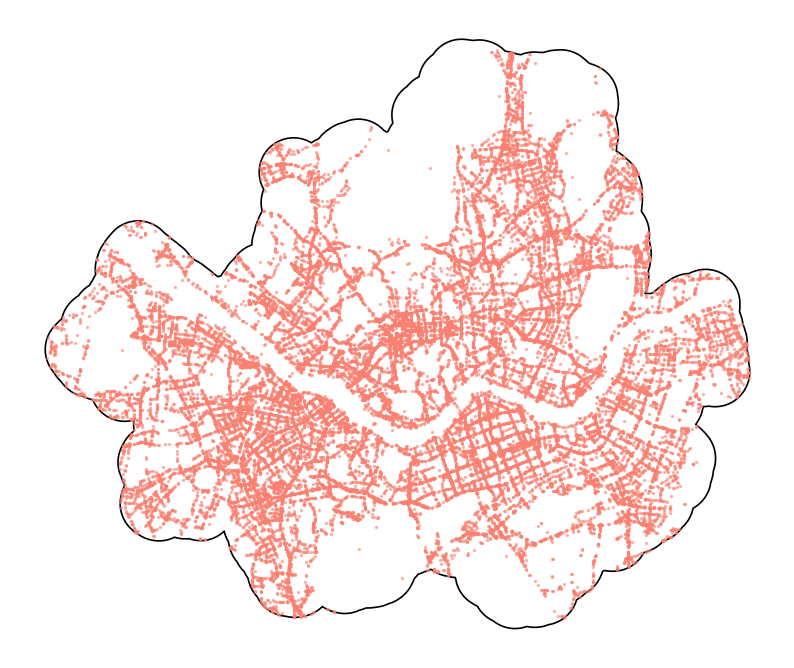

In [20]:
seoul_bound_buffer_2000 = seoul_bound_5179.to_crs("EPSG:5179").copy()
seoul_bound_buffer_2000["geometry"] = seoul_bound_buffer_2000.buffer(2000)

node_seoul = gpd.sjoin(node_gdf,
                       seoul_bound_buffer_2000[["geometry"]],
                       how='inner',
                       predicate='within'
                       ).drop(columns='index_right')

print(f'서울 필터링 전후 레코드 수 차이: {len(node_gdf) - len(node_seoul)}')
    # 서울 필터링 전후 노드 레코드 수 차이: 122084
    
# 시각화
fig, ax = plt.subplots(figsize=(10, 10))
seoul_bound_buffer_2000.plot(ax=ax,
                             facecolor='None',
                             edgecolor='black',
                             linewidth=1.2)
node_seoul.plot(ax=ax,
                markersize=2,
                alpha=0.5,
                color='salmon')
ax.set_axis_off()
plt.show()


## KTDB Edges EDA

    # link 전체 339,900개
    # from_node → to_node 조합 중복 0
    # 결측 없음
    # length_m 결측 없음

In [21]:

link = link.rename(columns={
    0: "record_type",
    1: "from_node",
    2: "to_node",
    3: "length_km",
    4: "mode_code",
    5: "link_type",
    6: "lane",
    7: "capacity",
    8: "speed",
    9: "vdf",
    10: "cost"
})

link = link.drop(columns="record_type", errors="ignore")

link["length_m"] = link["length_km"] * 1000

print(f'\n엣지 데이터 구조 {link.shape}')
print(f'\n노드 to 노드 중복 확인: {link[["from_node", "to_node"]].duplicated().sum()}')

print("\n엣지 결측치 확인")
print(link.isna().sum())

print(f'\n{link.describe()}') 

print(f'\n링크 타입 확인:{link["link_type"].value_counts().sort_index()}')


엣지 데이터 구조 (339900, 11)

노드 to 노드 중복 확인: 0

엣지 결측치 확인
from_node    0
to_node      0
length_km    0
mode_code    0
link_type    0
lane         0
capacity     0
speed        0
vdf          0
cost         0
length_m     0
dtype: int64

           from_node        to_node      length_km      link_type  \
count  339900.000000  339900.000000  339900.000000  339900.000000   
mean   178773.665693  178773.185528       0.352042     135.051424   
std     75543.117755   75553.347084       1.156315     145.536253   
min         1.000000       1.000000       0.000001     101.000000   
25%    136117.000000  136112.750000       0.030000     104.000000   
50%    175059.500000  175052.500000       0.080000     107.000000   
75%    215693.250000  215695.250000       0.240000     107.000000   
max    901546.000000  901546.000000      49.100000     999.000000   

                lane       capacity          speed            vdf      cost  \
count  339900.000000  339900.000000  339900.000000  339900.000000 

## 서울 Nodes 위치 기반 공간 필터링
    # 서울 경계부에서 네트워크가 과도하게 절단되는 것을 방지하기 위해
    # link의 from_node 또는 to_node 중 하나라도 서울 버퍼 내부 node에 포함되면 link 유지
    # 유지된 link에 포함된 외부 node도 함께 포함하여 hop 확장 node 생성


전후결과 차이: 

    # 서울 버퍼 내 node: 34321
    # 1-hop 확장 node: 34580
    # 서울 버퍼 내부 link: 72613
    # 1-hop 확장 link: 73215

In [22]:
    # 서울 버퍼 내부 node를 1차 추출
    # link의 from_node 또는 to_node 중 하나라도 서울 버퍼 내부 node에 포함되면 link 유지
    # 유지된 link에 포함된 외부 node도 함께 포함하여 1-hop 확장 node 생성
    # 이는 서울 경계부에서 네트워크가 과도하게 절단되는 것을 방지하기 위한 처리임
seoul_node_ids = set(node_seoul["node_id"])

link_seoul = link[
    link["from_node"].isin(seoul_node_ids) &
    link["to_node"].isin(seoul_node_ids)
].copy()

link_seoul_hop = link[
    link["from_node"].isin(seoul_node_ids) |
    link["to_node"].isin(seoul_node_ids)
].copy()

node_ids_hop = set(link_seoul_hop["from_node"]) | set(link_seoul_hop["to_node"])

node_seoul_hop = node_gdf[
    node_gdf["node_id"].isin(node_ids_hop)
].copy()

print("서울 버퍼 내 node:", len(node_seoul))
print("1-hop 확장 node:", len(node_seoul_hop))

print("서울 버퍼 내부 link:", len(link_seoul))
print("1-hop 확장 link:", len(link_seoul_hop))

    # 서울 버퍼 내 node: 34321
    # 1-hop 확장 node: 34580
    # 서울 버퍼 내부 link: 72613
    # 1-hop 확장 link: 73215
    
link_seoul_hop.head()

서울 버퍼 내 node: 34321
1-hop 확장 node: 34580
서울 버퍼 내부 link: 72613
1-hop 확장 link: 73215


,from_node,to_node,length_km,mode_code,link_type,lane,capacity,speed,vdf,cost,length_m
0,1,202920,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0
1,1,203573,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0
2,1,203574,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0
3,1,203575,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0
4,2,202967,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0


## KTDB link 가중치 값 기반 교통 네트워크 그래프 생성

In [23]:
display(node_seoul_hop.head())
display(link_seoul_hop.head())



node_geom = node_seoul_hop[["node_id", "geometry"]].copy()

# from node 지오 붙이기
link_seoul_hop = link_seoul_hop.merge(node_geom.rename(columns={"node_id": "from_node",
                                                                "geometry": "from_geometry"}),
                                      on = "from_node",
                                      how = "left"
                                      )

# to node 지오 붙이기
link_node_seoul = link_seoul_hop.merge(node_geom.rename(columns={"node_id": "to_node",
                                                                 "geometry": "to_geometry"}),
                                       on = "to_node",
                                       how = 'left')

print(f"시작 노드 결측: {link_node_seoul['from_geometry'].isna().sum()}")
print(f"종료 노드 결측: {link_node_seoul['to_geometry'].isna().sum()}")

# 시작 노드 결측: 0
# 종료 노드 결측: 0
# 성공!

,node_id,x,y,geometry
0,1,309672.531,553998.188,POINT (953650.381 1953947.893)
1,2,309409.656,552692.938,POINT (953394.555 1952641.77)
2,3,310216.594,554550.188,POINT (954191.288 1954502.566)
3,4,308141.094,555991.063,POINT (952108.956 1955931.815)
4,5,309032.813,556487.813,POINT (952997.671 1956433.11)


,from_node,to_node,length_km,mode_code,link_type,lane,capacity,speed,vdf,cost,length_m
0,1,202920,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0
1,1,203573,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0
2,1,203574,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0
3,1,203575,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0
4,2,202967,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0


시작 노드 결측: 0
종료 노드 결측: 0


네트워크 구조: (73215, 14)
네트워크 crs: EPSG:5179
네트워크 지오타입: <StringArray>
['LineString']
Length: 1, dtype: str


,from_node,to_node,length_km,mode_code,link_type,lane,capacity,speed,vdf,cost,length_m,from_geometry,to_geometry,geometry
0,1,202920,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0,POINT (953650.381 1953947.893),POINT (954247.887 1953951.76),"LINESTRING (953650.381 1953947.893, 954247.887..."
1,1,203573,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0,POINT (953650.381 1953947.893),POINT (953546.973 1953920.353),"LINESTRING (953650.381 1953947.893, 953546.973..."
2,1,203574,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0,POINT (953650.381 1953947.893),POINT (953446.884 1954037.963),"LINESTRING (953650.381 1953947.893, 953446.884..."
3,1,203575,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0,POINT (953650.381 1953947.893),POINT (954024.342 1953905.337),"LINESTRING (953650.381 1953947.893, 954024.342..."
4,2,202967,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0,POINT (953394.555 1952641.77),POINT (953305.763 1952615.058),"LINESTRING (953394.555 1952641.77, 953305.763 ..."


link_type 분포
link_type
101      394
102      779
103     4469
104    46785
105      313
106      168
107     9319
108     1283
200     3105
201      524
300      934
301      938
302      368
400      100
401       36
402       22
999     3678
Name: count, dtype: int64

거리 통계


count    73215.000000
mean       140.468270
std        298.364371
min          0.950000
25%         30.000000
50%         60.000000
75%        140.000000
max      10140.000000
Name: length_m, dtype: float64

거리 결측: 0


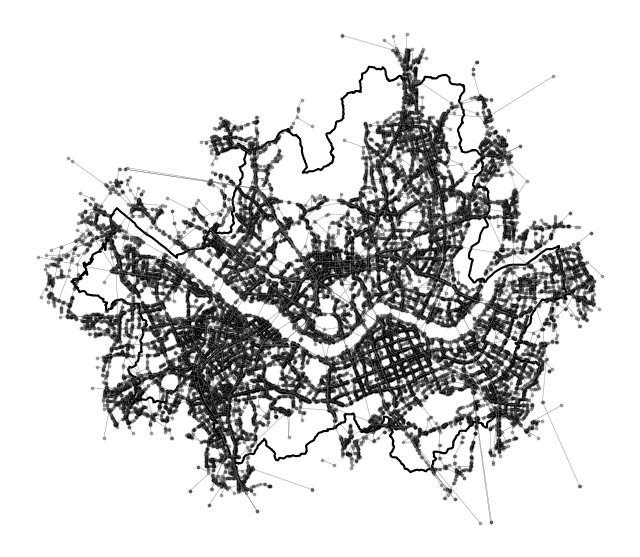

In [24]:
# link LineString으로 네트워크 생성
from shapely.geometry import LineString
link_node_seoul.head()

link_node_seoul["geometry"] = link_node_seoul.apply(lambda x: 
    LineString(
        [
            x["from_geometry"], 
            x["to_geometry"]
        ]
        ),
                      axis = 1)

transit_network = gpd.GeoDataFrame(link_node_seoul,
                                  geometry = "geometry",
                                  crs = "EPSG:5179")


# eda
print(f'네트워크 구조: {transit_network.shape}')
print(f'네트워크 crs: {transit_network.crs}')
print(f'네트워크 지오타입: {transit_network.geometry.geom_type.unique()}')
display(transit_network.head())
    # 네트워크 구조: (73215, 14)
    # 네트워크 crs: EPSG:5179
    # 네트워크 지오타입: <StringArray>
    # ['LineString']
    # 네트워크 엣지 개수 약 7만 3천개 
    
print("link_type 분포")
print(transit_network["link_type"].value_counts().sort_index())

print("\n거리 통계")
display(transit_network["length_m"].describe())

print("거리 결측:", transit_network["length_m"].isna().sum())

    # link_type 분포
    # link_type
    # 101      394
    # 102      779
    # 103     4469
    # 104    46785
    # 105      313
    # 106      168
    # 107     9319
    # 108     1283
    # 200     3105
    # 201      524
    # 300      934
    # 301      938
    # 302      368
    # 400      100
    # 401       36
    # 402       22
    # 999     3678
    # Name: count, dtype: int64

    # 거리 통계
    # count    73215.000000
    # mean       140.468270
    # std        298.364371
    # min          0.950000
    # 25%         30.000000
    # 50%         60.000000
    # 75%        140.000000
    # max      10140.000000
    # Name: length_m, dtype: float64
    # 거리 결측: 0

# 시각화
fig, ax = plt.subplots(figsize=(8, 8))

seoul_bound_5179.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.5
)

transit_network.plot(
    ax=ax,
    linewidth=0.2,
    color="dimgray",
    alpha=0.7
)

node_seoul_hop.plot(
    ax=ax,
    markersize = 3,
    color = 'black',
    alpha = 0.3
)

ax.set_axis_off()

plt.show()



## 대중 교통 노선 기반 네트워크 만들기

    # TransitPath의 노선별 연속 node 쌍을 KTDB link 테이블과 매칭한 결과,
    # 서울 2km 버퍼 및 hop 확장 범위 내 대중교통 path edge 350,215개 중
    # 350,000개 이상이 KTDB link 거리정보와 정상 매칭
    # 미매칭 edge는 230개로 전체의 약 0.07%에 불과,
    # KTDB node-link 기반 대중교통 네트워크 구성에는 큰 문제가 없는 것으로 판단하였다.

    # 서울권 대중교통 path edge 350,215개 중 349,985개는 KTDB link와 정방향 매칭
    # 정방향으로 매칭되지 않은 230개 중 157개는 동일 node 쌍의 역방향 link 거리정보로 보완 
    # 최종적으로 거리정보가 없는 edge는 73개이며, 전체의 약 0.02%
    # 대중교통 edge는 거리정보가 존재하는 350,142개 edge로 구성

In [25]:
 
# Line_ID별 노드 통과 순서 정렬
path_sorted = transit_path.sort_values(["Line_ID", "Seq"]).copy()

# 다음 노드 붙이기
path_sorted["to_node"] = (
    path_sorted
    .groupby("Line_ID")["Node_id"]
    .shift(-1)
)

# 마지막 노드는 다음 노드가 없으므로 제거
transit_path_edge = path_sorted[
    path_sorted["to_node"].notna()
].copy()

# from_node 정리
transit_path_edge = transit_path_edge.rename(columns={
    "Node_id": "from_node"
})

transit_path_edge["to_node"] = transit_path_edge["to_node"].astype(int)

transit_path_edge = transit_path_edge[[
    "Line_ID",
    "Seq",
    "from_node",
    "to_node",
    "Station_Y/N"
]].copy()

print("대중교통 노선 edge 후보:", transit_path_edge.shape)
display(transit_path_edge.head())

link_cost = transit_network[[
    "from_node", "to_node", "length_m", "link_type"
]].copy()

transit_path_edge = transit_path_edge.merge(
    link_cost,
    on=["from_node", "to_node"],
    how="left"
)

print("link 매칭 결측:", transit_path_edge["length_m"].isna().sum())
print("전체 edge:", len(transit_path_edge))

대중교통 노선 edge 후보: (1427195, 5)


,Line_ID,Seq,from_node,to_node,Station_Y/N
0,1000,1,202829,202879,1
1,1000,2,202879,202880,1
2,1000,3,202880,203996,1
3,1000,4,203996,203995,1
4,1000,5,203995,203994,1


link 매칭 결측: 1077210
전체 edge: 1427195


In [26]:
node_ids_hop = set(node_seoul_hop["node_id"])

transit_path_seoul = transit_path_edge[
    transit_path_edge["from_node"].isin(node_ids_hop) &
    transit_path_edge["to_node"].isin(node_ids_hop)
].copy()

print("전체 TransitPath edge:", len(transit_path_edge))
print("서울권 TransitPath edge:", len(transit_path_seoul))

print("서울권 edge 전체:", len(transit_path_seoul))
print("link 매칭 결측:", transit_path_seoul["length_m"].isna().sum())
print("결측 비율:", transit_path_seoul["length_m"].isna().mean())
    # 전체 TransitPath edge: 1427195
    # 서울권 TransitPath edge: 350215
    # 서울권 edge 전체: 350215
    # link 매칭 결측: 230
    # 결측 비율: 0.0006567394314920834
    
missing_transit_edge = transit_path_seoul[
    transit_path_seoul["length_m"].isna()
].copy()

display(missing_transit_edge.head(20))
print(missing_transit_edge["Line_ID"].value_counts().head(20))
print(missing_transit_edge["Station_Y/N"].value_counts(dropna=False))

missing_transit_edge = transit_path_seoul[
    transit_path_seoul["length_m"].isna()
].copy()

link_reverse_check = link[[
    "from_node", "to_node", "length_m", "link_type"
]].rename(columns={
    "from_node": "to_node",
    "to_node": "from_node",
    "length_m": "reverse_length_m",
    "link_type": "reverse_link_type"
})

missing_reverse_check = missing_transit_edge.merge(
    link_reverse_check,
    on=["from_node", "to_node"],
    how="left"
)

print("미매칭 edge:", len(missing_reverse_check))
print("역방향 link 존재:", missing_reverse_check["reverse_length_m"].notna().sum())
print("역방향 link 없음:", missing_reverse_check["reverse_length_m"].isna().sum())

전체 TransitPath edge: 1427195
서울권 TransitPath edge: 350215
서울권 edge 전체: 350215
link 매칭 결측: 230
결측 비율: 0.0006567394314920834


,Line_ID,Seq,from_node,to_node,Station_Y/N,length_m,link_type
91168,2037,161,197436,197380,1,NaN,NaN
91524,2040,89,195779,195829,0,NaN,NaN
93988,2056,46,201118,201123,0,NaN,NaN
94065,2057,64,200825,200811,1,NaN,NaN
94583,2060,123,201118,201123,1,NaN,NaN
103080,2113,23,170981,170999,1,NaN,NaN
103099,2113,42,171140,171151,0,NaN,NaN
103100,2113,43,171151,171150,0,NaN,NaN
103153,2113,96,171111,171150,0,NaN,NaN
103154,2113,97,171150,171151,0,NaN,NaN


Line_ID
2113    7
4396    6
4404    6
4407    6
4921    6
7788    6
3078    4
3954    4
4042    4
2114    3
2250    3
2251    3
3874    3
4036    3
4087    3
4408    3
7306    3
7448    3
7450    3
2248    2
Name: count, dtype: int64
Station_Y/N
0    198
1     32
Name: count, dtype: int64
미매칭 edge: 230
역방향 link 존재: 157
역방향 link 없음: 73


In [27]:
# 역방향 link 거리정보 붙이기
link_reverse_check = link[[
    "from_node", "to_node", "length_m", "link_type"
]].rename(columns={
    "from_node": "to_node",
    "to_node": "from_node",
    "length_m": "reverse_length_m",
    "link_type": "reverse_link_type"
})

transit_path_seoul = transit_path_seoul.merge(
    link_reverse_check,
    on=["from_node", "to_node"],
    how="left"
)

# 역방향 보완 전, 정방향 결측 여부 저장
forward_missing = transit_path_seoul["length_m"].isna()


# 정방향 매칭이 없을 때만 역방향 값으로 보완
transit_path_seoul["length_m"] = transit_path_seoul["length_m"].fillna(
    transit_path_seoul["reverse_length_m"]
)

transit_path_seoul["link_type"] = transit_path_seoul["link_type"].fillna(
    transit_path_seoul["reverse_link_type"]
)

# 매칭 방향 기록
transit_path_seoul["link_match_type"] = "forward"

transit_path_seoul.loc[
    forward_missing & transit_path_seoul["reverse_length_m"].notna(),
    "link_match_type"
] = "reverse_fill"

transit_path_seoul.loc[
    transit_path_seoul["length_m"].isna(),
    "link_match_type"
] = "unmatched"

print(transit_path_seoul["link_match_type"].value_counts())
print("최종 length_m 결측:", transit_path_seoul["length_m"].isna().sum())
print("최종 결측 비율:", transit_path_seoul["length_m"].isna().mean())

transit_path_seoul_valid = transit_path_seoul[
    transit_path_seoul["length_m"].notna()
].copy()

print("사용 edge:", len(transit_path_seoul_valid))
print("제외 edge:", len(transit_path_seoul) - len(transit_path_seoul_valid))
    # link_match_type
    # forward      350142
    # unmatched        73
    # Name: count, dtype: int64
    # 최종 length_m 결측: 73
    # 최종 결측 비율: 0.00020844338477792214
    # 사용 edge: 350142
    # 제외 edge: 73

link_match_type
forward         349985
reverse_fill       157
unmatched           73
Name: count, dtype: int64
최종 length_m 결측: 73
최종 결측 비율: 0.00020844338477792214
사용 edge: 350142
제외 edge: 73


## KTDB 노선별 표정속도 결합 및 시간 가중치 생성

In [28]:
# 노선별 표정속도 결합
transit_speed = transit_info[[
    "Line_ID", "Mode", "Type", "Name", "Commercial_Speed"
]].copy()

print("표정속도 테이블 Line_ID 중복:", transit_speed["Line_ID"].duplicated().sum())

transit_path_seoul_valid = transit_path_seoul_valid.merge(
    transit_speed,
    on="Line_ID",
    how="left"
)

print("Commercial_Speed 결측:", transit_path_seoul_valid["Commercial_Speed"].isna().sum())

# 표정속도 기반 edge 이동시간 생성
transit_path_seoul_valid["대중교통_edge시간"] = (
    transit_path_seoul_valid["length_m"] /
    (transit_path_seoul_valid["Commercial_Speed"] * 1000 / 60)
)

display(transit_path_seoul_valid[[
    "length_m", "Commercial_Speed", "대중교통_edge시간"
]].describe())

표정속도 테이블 Line_ID 중복: 0
Commercial_Speed 결측: 0


,length_m,Commercial_Speed,대중교통_edge시간
count,350142.000000,350142.000000,350142.000000
mean,162.779433,31.845129,0.270669
std,382.345340,12.953822,0.512059
min,0.950000,18.144330,0.001900
25%,30.000000,30.000000,0.060000
50%,60.000000,30.000000,0.120000
75%,140.000000,30.000000,0.280000
max,10140.000000,228.910000,12.280000


In [29]:
# 같은 from_node-to_node가 여러 노선에 반복될 수 있으므로
# 시간 기준으로 가장 짧은 edge만 그래프에 사용
transit_edge_for_graph = (
    transit_path_seoul_valid
    .sort_values("대중교통_edge시간")
    .drop_duplicates(["from_node", "to_node"], keep="first")
    .copy()
)

# NetworkX 대중교통 시간 그래프 생성
transit_graph = nx.DiGraph()

for row in transit_edge_for_graph.itertuples(index=False):
    transit_graph.add_edge(
        row.from_node,
        row.to_node,
        time_min=row.대중교통_edge시간,
        length=row.length_m,
        Line_ID=row.Line_ID,
        Mode=row.Mode,
        link_type=row.link_type
    )

print("대중교통 그래프용 edge:", len(transit_edge_for_graph))
print("대중교통 그래프 노드 수:", transit_graph.number_of_nodes())
print("대중교통 그래프 엣지 수:", transit_graph.number_of_edges())
    # 대중교통 그래프용 edge: 49451
    # 대중교통 그래프 노드 수: 28058
    # 대중교통 그래프 엣지 수: 49451

대중교통 그래프용 edge: 49451
대중교통 그래프 노드 수: 28058
대중교통 그래프 엣지 수: 49451


## 가맹점 POI - 대중교통 노드 snapping

In [30]:
# 대중교통 그래프에 실제로 포함된 node만 추출
transit_graph_node_ids = list(transit_graph.nodes)

transit_node = node_seoul_hop[
    node_seoul_hop["node_id"].isin(transit_graph_node_ids)
].copy()

print("대중교통 그래프 node 수:", len(transit_graph_node_ids))
print("대중교통 node geometry 테이블:", transit_node.shape)


# 격자 준비
transit_grid = grid.copy()
transit_grid = transit_grid.to_crs("EPSG:5179")

transit_grid["중심점"] = gpd.points_from_xy(
    transit_grid["중심점_x"],
    transit_grid["중심점_y"],
    crs="EPSG:5179"
)

transit_grid_point = gpd.GeoDataFrame(
    transit_grid.drop(columns="geometry", errors="ignore"),
    geometry="중심점",
    crs="EPSG:5179"
)

# 가맹점 준비
transit_store = store.copy()
transit_store = transit_store.to_crs("EPSG:5179")
# node geometry 이름 정리
transit_node_nearest = transit_node[["node_id", "geometry"]].copy()
transit_node_nearest = transit_node_nearest.rename(columns={
    "node_id": "대중교통_노드ID",
    "geometry": "대중교통_노드_geometry"
})

transit_node_nearest = gpd.GeoDataFrame(
    transit_node_nearest,
    geometry="대중교통_노드_geometry",
    crs="EPSG:5179"
)
# 격자 - 대중교통 node 최근접 연결
transit_grid_snap = gpd.sjoin_nearest(
    transit_grid_point,
    transit_node_nearest,
    how="left",
    distance_col="대중교통_스냅거리"
)

print("격자 대중교통 노드 결측:", transit_grid_snap["대중교통_노드ID"].isna().sum())
print(transit_grid_snap["대중교통_스냅거리"].describe())
# 가맹점 - 대중교통 node 최근접 연결
transit_store_snap = gpd.sjoin_nearest(
    transit_store,
    transit_node_nearest,
    how="left",
    distance_col="대중교통_스냅거리"
)

print("가맹점 대중교통 노드 결측:", transit_store_snap["대중교통_노드ID"].isna().sum())
print(transit_store_snap["대중교통_스냅거리"].describe())

대중교통 그래프 node 수: 28058
대중교통 node geometry 테이블: (28058, 4)
격자 대중교통 노드 결측: 0
count    60528.000000
mean       286.147231
std        402.001347
min          0.470703
25%         73.373515
50%        144.626934
75%        302.594814
max       3212.428991
Name: 대중교통_스냅거리, dtype: float64
가맹점 대중교통 노드 결측: 0
count    4702.000000
mean       84.219739
std        71.811936
min         3.371322
25%        36.585805
50%        62.012971
75%       107.272933
max       831.569988
Name: 대중교통_스냅거리, dtype: float64


## 대중교통 기준 접근성 허용 시간 metric 결정

- 수식:

  `대중교통_edge시간 = length_m / (Commercial_Speed × 1000 / 60)`

  `격자_탑승접근시간 = max(격자_스냅거리 - 35.35m, 0) / 75`

  `가맹점_하차접근시간 = 가맹점_스냅거리 / 75`

  `대중교통_최종시간 = 격자_탑승접근시간 + 대중교통_네트워크시간 + 가맹점_하차접근시간`

- 설계:

  대중교통 접근성 기준은 지역거점시설 접근 기준인 차량 약 20분·10km를 참고하여 20분으로 설정함. 
  
  네트워크 내부 이동시간은 KTDB 노선별 표정속도 `Commercial_Speed`로 계산하고, 
  
  격자-탑승 node 및 하차 node-가맹점 구간은 도보 접근 기준과 동일한 보행속도 75m/min을 적용함. 
  
  배차간격과 환승 대기시간은 본 metric에는 포함하지 않음.


In [31]:
# 선행연구 기준: 마을단위시설 도보 약 10분·750m
# 750m / 10분 = 75m/min
walk_speed_m_per_min = 75

# 기존 도보 네트워크 분석과 동일한 100m 격자 중심점 보정값
grid_snap_offset = (70.7 + 0) / 2

# 격자 중심점 스냅거리 보정
transit_grid_snap["대중교통_스냅거리_보정"] = (
    transit_grid_snap["대중교통_스냅거리"] - grid_snap_offset
).clip(lower=0)

# 격자 → 탑승 node 도보시간
transit_grid_snap["대중교통_탑승접근시간"] = (
    transit_grid_snap["대중교통_스냅거리_보정"] / walk_speed_m_per_min
)

# 하차 node → 가맹점 도보시간
transit_store_snap["대중교통_하차접근시간"] = (
    transit_store_snap["대중교통_스냅거리"] / walk_speed_m_per_min
)

print("격자 탑승접근시간")
display(transit_grid_snap["대중교통_탑승접근시간"].describe())

print("가맹점 하차접근시간")
display(transit_store_snap["대중교통_하차접근시간"].describe())

격자 탑승접근시간


count    60528.000000
mean         3.361040
std          5.348913
min          0.000000
25%          0.506980
50%          1.457026
75%          3.563264
max         42.361053
Name: 대중교통_탑승접근시간, dtype: float64

가맹점 하차접근시간


count    4702.000000
mean        1.122930
std         0.957492
min         0.044951
25%         0.487811
50%         0.826840
75%         1.430306
max        11.087600
Name: 대중교통_하차접근시간, dtype: float64

In [32]:
# 스냅거리 이상치 후보 확인
grid_transit_snap_out = transit_grid_snap[
    transit_grid_snap["대중교통_스냅거리"] > 500
].copy()

store_transit_snap_out = transit_store_snap[
    transit_store_snap["대중교통_스냅거리"] > 300
].copy()

print("격자 대중교통 스냅거리 500m 초과:", len(grid_transit_snap_out))
print("가맹점 대중교통 스냅거리 300m 초과:", len(store_transit_snap_out))

display(grid_transit_snap_out[
    ["GRID_CD", "시군구", "행정동", "문화누리대상자_추정_인구수", "대중교통_스냅거리"]
].sort_values("대중교통_스냅거리", ascending=False).head(20))

display(store_transit_snap_out[
    ["가맹점_ID", "가맹점명", "중분류", "소분류", "시군구", "대중교통_스냅거리"]
].sort_values("대중교통_스냅거리", ascending=False).head(20))

격자 대중교통 스냅거리 500m 초과: 8855
가맹점 대중교통 스냅거리 300m 초과: 81


,GRID_CD,시군구,행정동,문화누리대상자_추정_인구수,대중교통_스냅거리
60273,다사566659,도봉구,도봉1동,0.0,3212.428991
60216,다사566658,도봉구,도봉1동,0.0,3130.986101
60329,다사567660,도봉구,도봉1동,0.0,3114.421137
60217,다사567658,도봉구,도봉1동,0.0,3113.650334
60274,다사567659,도봉구,도봉1동,0.0,3112.429712
60157,다사566657,도봉구,도봉1동,0.0,3031.660058
60158,다사567657,도봉구,도봉1동,0.0,3021.513635
60159,다사568657,도봉구,도봉1동,0.0,3014.651984
60330,다사568660,도봉구,도봉1동,0.0,3014.487967
60218,다사568658,도봉구,도봉1동,0.0,3013.691605


,가맹점_ID,가맹점명,중분류,소분류,시군구,대중교통_스냅거리
927,STORE_00928,교보문고 서울대점 (서울대학교생활협동조합),도서,도서,관악구,831.569988
3174,STORE_03175,이랜드크루즈 (주 이크루즈누에나루),교통수단,여객선,송파구,822.514581
783,STORE_00784,아시아나항공(주),교통수단,국내항공,강서구,687.096977
893,STORE_00894,화곡다목적체육관(강서구시설관리공단),체육시설,체육시설,강서구,641.038372
1763,STORE_01764,현대 글마당 삼육대학교 구내서점(현대문구 삼육대점),도서,도서,노원구,608.320987
1720,STORE_01721,주식회사 티알큐,문화체험,문화체험,노원구,608.320987
635,STORE_00636,강서다목적체육관(강서구시설관리공단),체육시설,체육시설,강서구,600.480679
3748,STORE_03749,대성서점문구,미술,공예,은평구,556.139505
1911,STORE_01912,경희대소비자생활협동조합서점,도서,도서,동대문구,541.054784
3209,STORE_03210,티막스토어 올림픽점(티막 올림픽점),체육용품,체육용품,송파구,522.340600


## 대중교통 접근 대상 가맹점 필터링


In [33]:
# 대중교통 접근성 분석 대상 중분류
transit_columns = ["미술", "공연", "스포츠관람", "관광지"]

# 대중교통 접근 허용시간: 지역거점시설 기준 차량 약 20분
transit_time_limit = 20

# 대중교통 node ID 타입 정리
transit_grid_snap = transit_grid_snap.copy()
transit_store_snap = transit_store_snap.copy()

transit_grid_snap["대중교통_노드ID"] = transit_grid_snap["대중교통_노드ID"].astype(int)
transit_store_snap["대중교통_노드ID"] = transit_store_snap["대중교통_노드ID"].astype(int)

# 접근성 분석 전에 대중교통 대상 가맹점만 먼저 필터링
transit_store_target = transit_store_snap[
    transit_store_snap["중분류"].isin(transit_columns)
].copy()

print("대중교통 분석 대상 가맹점 수:", len(transit_store_target))
print("대중교통 분석 대상 가맹점 node 수:", transit_store_target["대중교통_노드ID"].nunique())
print(transit_store_target["중분류"].value_counts())


대중교통 분석 대상 가맹점 수: 1134
대중교통 분석 대상 가맹점 node 수: 933
중분류
미술       876
공연       187
관광지       53
스포츠관람     18
Name: count, dtype: int64


## Reverse Dijkstra 기반 대중교통 접근 가능 pair 생성


In [34]:
import time

# 격자를 대중교통 node별로 묶기
node_grid_dict = defaultdict(list)

for idx, row in transit_grid_snap.iterrows():
    node_grid_dict[row["대중교통_노드ID"]].append(idx)

# 가맹점을 대중교통 node별로 묶기
node_store_dict = defaultdict(list)

for idx, row in transit_store_target.iterrows():
    node_store_dict[row["대중교통_노드ID"]].append(idx)

# 행 조회용 딕셔너리
grid_info = transit_grid_snap.to_dict("index")
store_info = transit_store_target.to_dict("index")

print("격자가 붙은 대중교통 node 수:", len(node_grid_dict))
print("대중교통 대상 가맹점이 붙은 node 수:", len(node_store_dict))

# 도착지인 가맹점 node에서 역방향 그래프를 탐색하면
# 원래 방향 기준으로 해당 가맹점까지 도달 가능한 출발 node를 찾을 수 있음
transit_graph_reverse = transit_graph.reverse(copy=True)

min_grid_access_time = transit_grid_snap["대중교통_탑승접근시간"].min()

transit_reach_rows = []
start_time = time.time()
total_store_node_count = len(node_store_dict)

for n, (store_node, store_idx_list) in enumerate(node_store_dict.items(), start=1):

    if store_node not in transit_graph_reverse:
        continue

    min_store_access_time = min(
        store_info[store_idx]["대중교통_하차접근시간"]
        for store_idx in store_idx_list
    )

    network_cutoff = transit_time_limit - min_grid_access_time - min_store_access_time

    if network_cutoff <= 0:
        continue

    # store_node까지 20분 안에 도달 가능한 출발 node를 역방향 그래프에서 탐색
    lengths = nx.single_source_dijkstra_path_length(
        transit_graph_reverse,
        store_node,
        cutoff=network_cutoff,
        weight="time_min"
    )

    # 도달 가능한 node 중 격자가 붙은 node만 후보로 사용
    for grid_node, network_time in lengths.items():
        grid_idx_list = node_grid_dict.get(grid_node, [])

        if len(grid_idx_list) == 0:
            continue

        for grid_idx in grid_idx_list:
            grid_row = grid_info[grid_idx]
            grid_access_time = grid_row["대중교통_탑승접근시간"]

            for store_idx in store_idx_list:
                store_row = store_info[store_idx]
                store_access_time = store_row["대중교통_하차접근시간"]

                final_time = (
                    grid_access_time
                    + network_time
                    + store_access_time
                )

                if final_time <= transit_time_limit:
                    transit_reach_rows.append({
                        "GRID_CD": grid_row["GRID_CD"],
                        "대중교통_네트워크시간": network_time,
                        "격자_스냅거리": grid_row["대중교통_스냅거리"],
                        "격자_스냅거리_보정": grid_row["대중교통_스냅거리_보정"],
                        "격자_탑승접근시간": grid_access_time,
                        "가맹점_스냅거리": store_row["대중교통_스냅거리"],
                        "가맹점_하차접근시간": store_access_time,
                        "대중교통_최종시간": final_time,
                        "가맹점_ID": store_row["가맹점_ID"],
                    })

    if n % 50 == 0:
        elapsed_min = (time.time() - start_time) / 60
        print(f"{n:,} / {total_store_node_count:,}개 가맹점 node 처리 완료 | {elapsed_min:.1f}분")

grid_store_transit_reach = pd.DataFrame(transit_reach_rows)

print("대중교통 접근 가능 pair 수:", len(grid_store_transit_reach))
display(grid_store_transit_reach.head())


격자가 붙은 대중교통 node 수: 16300
대중교통 대상 가맹점이 붙은 node 수: 933
50 / 933개 가맹점 node 처리 완료 | 0.1분
100 / 933개 가맹점 node 처리 완료 | 0.2분
150 / 933개 가맹점 node 처리 완료 | 0.2분
200 / 933개 가맹점 node 처리 완료 | 0.3분
250 / 933개 가맹점 node 처리 완료 | 0.4분
300 / 933개 가맹점 node 처리 완료 | 0.5분
350 / 933개 가맹점 node 처리 완료 | 0.6분
400 / 933개 가맹점 node 처리 완료 | 0.7분
450 / 933개 가맹점 node 처리 완료 | 0.8분
500 / 933개 가맹점 node 처리 완료 | 0.9분
550 / 933개 가맹점 node 처리 완료 | 1.0분
600 / 933개 가맹점 node 처리 완료 | 1.1분
650 / 933개 가맹점 node 처리 완료 | 1.2분
700 / 933개 가맹점 node 처리 완료 | 1.3분
750 / 933개 가맹점 node 처리 완료 | 1.4분
800 / 933개 가맹점 node 처리 완료 | 1.7분
850 / 933개 가맹점 node 처리 완료 | 1.8분
900 / 933개 가맹점 node 처리 완료 | 2.0분
대중교통 접근 가능 pair 수: 11343854


,GRID_CD,대중교통_네트워크시간,격자_스냅거리,격자_스냅거리_보정,격자_탑승접근시간,가맹점_스냅거리,가맹점_하차접근시간,대중교통_최종시간,가맹점_ID
0,다사539520,0.00,83.297654,47.947654,0.639302,96.433604,1.285781,1.925083,STORE_00008
1,다사539520,0.00,83.297654,47.947654,0.639302,96.433604,1.285781,1.925083,STORE_01670
2,다사539520,0.00,83.297654,47.947654,0.639302,96.433604,1.285781,1.925083,STORE_02428
3,다사539520,0.00,83.297654,47.947654,0.639302,96.433604,1.285781,1.925083,STORE_03198
4,다사540519,0.12,21.190156,0.000000,0.000000,96.433604,1.285781,1.405781,STORE_00008


## 대중교통 접근성 분석 결과 검토


In [35]:
print("격자코드 - 가맹점 ID 중복 확인:", grid_store_transit_reach[["GRID_CD", "가맹점_ID"]].duplicated().sum())
print("기준 시간 초과 레코드 확인:", (grid_store_transit_reach["대중교통_최종시간"] > transit_time_limit).sum())
print("연결된 격자 개수:", grid_store_transit_reach["GRID_CD"].nunique())
print("연결된 가맹점 개수:", grid_store_transit_reach["가맹점_ID"].nunique())

transit_grid_stat = (
    grid_store_transit_reach
    .groupby("GRID_CD")["가맹점_ID"]
    .size()
    .reset_index(name="가맹점_개수")
)

print("격자별 접근 가능한 대중교통 가맹점 통계량")
display(transit_grid_stat["가맹점_개수"].describe())

display(grid_store_transit_reach.head())


격자코드 - 가맹점 ID 중복 확인: 0
기준 시간 초과 레코드 확인: 0
연결된 격자 개수: 56100
연결된 가맹점 개수: 1134
격자별 접근 가능한 대중교통 가맹점 통계량


count    56100.000000
mean       202.207736
std        135.688946
min          1.000000
25%        101.000000
50%        177.000000
75%        285.000000
max        546.000000
Name: 가맹점_개수, dtype: float64

,GRID_CD,대중교통_네트워크시간,격자_스냅거리,격자_스냅거리_보정,격자_탑승접근시간,가맹점_스냅거리,가맹점_하차접근시간,대중교통_최종시간,가맹점_ID
0,다사539520,0.00,83.297654,47.947654,0.639302,96.433604,1.285781,1.925083,STORE_00008
1,다사539520,0.00,83.297654,47.947654,0.639302,96.433604,1.285781,1.925083,STORE_01670
2,다사539520,0.00,83.297654,47.947654,0.639302,96.433604,1.285781,1.925083,STORE_02428
3,다사539520,0.00,83.297654,47.947654,0.639302,96.433604,1.285781,1.925083,STORE_03198
4,다사540519,0.12,21.190156,0.000000,0.000000,96.433604,1.285781,1.405781,STORE_00008


## 도보·대중교통 접근성 통합 테이블 생성


In [36]:
# 도보 접근성 테이블 형식 정리
access_walk_final = access_walk.copy()

if "접근비용" not in access_walk_final.columns:
    access_walk_final["접근비용"] = access_walk_final["접근거리"]

access_walk_final = access_walk_final.drop(columns="접근거리", errors="ignore")

# 대중교통 접근성 테이블 - 격자 병합
transit_reach_merge = grid_store_transit_reach[
    ["GRID_CD", "대중교통_최종시간", "가맹점_ID"]
].copy()

transit_reach_merge.rename(columns={
    "대중교통_최종시간": "접근비용"
}, inplace=True)

access_transit_grid = transit_reach_merge.merge(
    grid_reach_merge,
    on="GRID_CD",
    how="left"
)

# 대중교통 접근성 테이블 - 가맹점 병합
access_transit = access_transit_grid.merge(
    store_reach_merge,
    on="가맹점_ID",
    how="left"
)

access_transit = access_transit[
    access_transit["중분류"].isin(transit_columns)
].copy()

access_transit["접근수단"] = "대중교통"

# 최종 통합 접근성 테이블
access_columns = [
    "GRID_CD",
    "가맹점_ID",
    "접근수단",
    "접근비용",
    "시군구_격자",
    "행정동_격자",
    "추정_인구수",
    "문화누리대상자_추정_인구수",
    "가맹점명",
    "시군구_가맹점",
    "대분류",
    "중분류",
    "소분류",
    "전화결제",
    "장애인친화시설",
    "찾아가는문화서비스",
]

access_table = pd.concat(
    [
        access_walk_final[access_columns],
        access_transit[access_columns],
    ],
    ignore_index=True
)

print("통합 접근성 테이블 구조:", access_table.shape)
print("결측치 확인")
print(access_table.isna().sum())
print("GRID_CD-가맹점_ID-접근수단 중복:", access_table[["GRID_CD", "가맹점_ID", "접근수단"]].duplicated().sum())
print("접근수단별 레코드 수")
print(access_table["접근수단"].value_counts())
print("중분류별 레코드 수")
print(access_table["중분류"].value_counts())

display(access_table.head())


통합 접근성 테이블 구조: (11612916, 16)
결측치 확인
GRID_CD           0
가맹점_ID            0
접근수단              0
접근비용              0
시군구_격자            0
행정동_격자            0
추정_인구수            0
문화누리대상자_추정_인구수    0
가맹점명              0
시군구_가맹점           0
대분류               0
중분류               0
소분류               0
전화결제              0
장애인친화시설           0
찾아가는문화서비스         0
dtype: int64
GRID_CD-가맹점_ID-접근수단 중복: 0
접근수단별 레코드 수
접근수단
대중교통    11343854
도보        269062
Name: count, dtype: int64
중분류별 레코드 수
중분류
미술       8846630
공연       1883485
관광지       482906
스포츠관람     130833
체육시설      107683
도서         54535
문화체험       52763
체육용품       30070
음악         14517
영상          9494
Name: count, dtype: int64


,GRID_CD,가맹점_ID,접근수단,접근비용,시군구_격자,행정동_격자,추정_인구수,문화누리대상자_추정_인구수,가맹점명,시군구_가맹점,대분류,중분류,소분류,전화결제,장애인친화시설,찾아가는문화서비스
0,다사666408,STORE_00077,도보,597.836083,강남구,세곡동,0,0.00000,드림골프샵(드림통상),강남구,체육,체육용품,체육용품,1,1,0
1,다사574540,STORE_02878,도보,300.075335,성북구,보문동,258,11.51174,삼천리자전거 보문점,성북구,체육,체육용품,체육용품,0,0,0
2,다사574540,STORE_02915,도보,339.379423,성북구,보문동,258,11.51174,안암동 주민자치회,성북구,문화,문화체험,문화체험,0,0,0
3,다사574540,STORE_02890,도보,461.404402,성북구,보문동,258,11.51174,성북실내풋살센터,성북구,체육,체육시설,체육시설,0,0,0
4,다사574540,STORE_02976,도보,539.688872,성북구,보문동,258,11.51174,크로스핏 로꼬,성북구,체육,체육시설,체육시설,0,0,0


## 접근성 분석 산출물 저장


In [ ]:
# 도보 스냅거리 보정값 생성
if "격자_스냅거리_보정" not in walk_grid_snap.columns:
    walk_grid_snap["격자_스냅거리_보정"] = (
        walk_grid_snap["도보_스냅거리"] - grid_snap_offset
    ).clip(lower=0)

# 최종 접근성 테이블
access_table.to_csv(
    OUTPUT_PATH / "문화누리_격자_가맹점_접근성_통합테이블.csv",
    index=False,
    encoding="utf-8-sig"
)

# 이동수단별 접근 가능 pair 테이블
grid_store_walk_reach.to_csv(
    OUTPUT_PATH / "도보_네트워크_접근성.csv",
    index=False,
    encoding="utf-8-sig"
)

grid_store_transit_reach.to_csv(
    OUTPUT_PATH / "대중교통_네트워크_접근성.csv",
    index=False,
    encoding="utf-8-sig"
)

# 도보 그래프 데이터
walk_node.reset_index().to_file(
    OUTPUT_PATH / "도보_네트워크_nodes.gpkg",
    driver="GPKG"
)

walk_edge.reset_index().to_file(
    OUTPUT_PATH / "도보_네트워크_edges.gpkg",
    driver="GPKG"
)

ox.save_graphml(
    walk_graph,
    filepath=OUTPUT_PATH / "도보_네트워크_graph.graphml"
)

# 대중교통 그래프 데이터
transit_node.to_file(
    OUTPUT_PATH / "대중교통_네트워크_nodes.gpkg",
    driver="GPKG"
)

transit_edge_for_graph.to_csv(
    OUTPUT_PATH / "대중교통_네트워크_edges.csv",
    index=False,
    encoding="utf-8-sig"
)

nx.write_graphml(
    transit_graph,
    OUTPUT_PATH / "대중교통_네트워크_graph.graphml"
)

# 격자-node 연결 테이블
walk_grid_snap[
    ["GRID_CD", "도보_노드ID", "도보_스냅거리", "격자_스냅거리_보정"]
].to_csv(
    OUTPUT_PATH / "격자_도보노드_연결테이블.csv",
    index=False,
    encoding="utf-8-sig"
)

transit_grid_snap[
    [
        "GRID_CD",
        "대중교통_노드ID",
        "대중교통_스냅거리",
        "대중교통_스냅거리_보정",
        "대중교통_탑승접근시간",
    ]
].to_csv(
    OUTPUT_PATH / "격자_대중교통노드_연결테이블.csv",
    index=False,
    encoding="utf-8-sig"
)

# 가맹점-node 연결 테이블
walk_store_snap[
    ["가맹점_ID", "도보_노드ID", "도보_스냅거리"]
].to_csv(
    OUTPUT_PATH / "가맹점_도보노드_연결테이블.csv",
    index=False,
    encoding="utf-8-sig"
)

transit_store_snap[
    ["가맹점_ID", "대중교통_노드ID", "대중교통_스냅거리", "대중교통_하차접근시간"]
].to_csv(
    OUTPUT_PATH / "가맹점_대중교통노드_연결테이블.csv",
    index=False,
    encoding="utf-8-sig"
)


접근성 분석 산출물 저장 완료
